# AI Security Framework Crosswalk: Exploratory Visual Analysis

**Author:** Rock Lambros, University of Denver, COMP 4433 Project 1

## Abstract

This notebook explores a knowledge graph that links nine AI security frameworks
into a single crosswalk containing 983 nodes and 5,813 edges. The frameworks
are AIUC-1, CSA AICM, CoSAI Risk Map, EU GPAI Code of Practice, MITRE ATLAS,
NIST AI RMF, OWASP Agentic AI, OWASP AI Exchange, and OWASP LLM Top 10.
The goal is to build a classifier that, given any two nodes from different
frameworks, predicts whether the pair is *Unrelated*, *Partial*, *Related*,
or *Equivalent*.

The production classifier referenced throughout this notebook is the
**v6 reframed pipeline**. It takes three inputs for every candidate pair — a
Claude Sonnet 4 triple-vote similarity score, a pre-computed structural feature
vector derived from graph depth, description length, Node2Vec, and a graph
attention network (GAT) embedding, and a Claude Opus calibration score — and
stacks them into a **22-dimensional feature vector** (7 LLM + 13 structural +
2 Opus). A single gradient boosting classifier (sklearn `GradientBoostingClassifier`)
trained on **150 human-labeled calibration pairs** predicts the four-tier
label for each candidate, and a split-conformal calibration procedure emits a
prediction *set* with a 90% coverage guarantee. Final evaluation is on a frozen
holdout of **400 expert-labeled pairs**. The entire decision is the GBM acting
on these 22 features — no transformer fine-tuning and no hand-tuned weighted
composites are used anywhere in the pipeline.

The intended reader is a scientific audience that wants to know whether the
choices this classifier is making are defensible. Every figure is paired with a
narrative that walks through what the visualization shows and why it is
informative for that question. No model training happens in the notebook
itself. All feature matrices, feature importances, ablation scores, confusion
matrices, bootstrap confidence intervals, and conformal prediction sets are
read from pre-computed CSV and JSON artifacts produced by the v6 training and
sacred evaluation scripts.

The "reframed" in *v6 reframed* distinguishes this generation from five prior
pipeline rewrites. If you want the full lineage — what v1 through v5 were,
what I changed at each step, and what each iteration taught me about the
problem — see **§9 · Pipeline Evolution: v1 → v6** at the end of the notebook.
The rest of the notebook focuses on v6 itself.

> **Plain English:** I built a tool that compares security controls across nine different AI security standards and decides how closely any two controls are related. The final model combines three signals: what Claude thinks about the similarity, what the graph structure looks like, and a second Claude calibration score. I feed 22 numbers per pair into a gradient boosting model and it picks one of four tiers. This notebook explores the data and the model's behavior using only standard Python data science tools.

## 2 · Setup and Data Loading

All artifacts referenced below live in `data/processed/` and `results/sacred/`. The training pipeline writes them as part of its normal run, and the notebook only reads them. The intent is to keep this notebook reproducible from any machine that has the submission zip, without requiring access to a GPU or the embedding models.

In [1]:
# Only COMP 4433 approved libraries are imported: numpy, pandas, matplotlib,
# seaborn, sklearn, statsmodels. Loading everything up front makes it obvious
# which files the notebook depends on and fails fast if any are missing.
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns

# Resolve the repo root in a way that works whether the notebook is launched
# from the repo root, from notebooks/, or from a fresh unzipped submission
# folder. I walk upward looking for the data/processed directory rather than
# relying on a hard-coded relative path.
HERE = Path.cwd()
candidate = HERE
for _ in range(4):
    if (candidate / "data" / "processed").exists():
        break
    candidate = candidate.parent
REPO = candidate
DATA = REPO / "data" / "processed"
SACRED = REPO / "results" / "sacred"
assert DATA.exists(), f"could not locate data/processed starting from {HERE}"

# Seaborn theme. The paper context and bold titles match a scientific
# document rather than a slide deck. I set savefig DPI high enough that PDF
# and PNG exports remain crisp if the grader rerenders the notebook.
sns.set_theme(style="whitegrid", context="paper", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.frameon": False,
})

def jload(name):
    return json.loads((DATA / name).read_text())

def cload(name):
    return pd.read_csv(DATA / name)

# Graph artifacts. nodes.json and edges.json are the canonical long-form tables
# that describe the crosswalk. graph_stats.json is a small summary precomputed
# once at ingest time so the notebook does not have to reaggregate from scratch.
nodes = jload("nodes.json")
edges = jload("edges.json")
graph_stats = jload("graph_stats.json")

# v6 artifacts. The feature CSVs hold the 22-dimensional input the classifier
# sees, one row per expert-labeled pair. v6_all_results.json holds feature
# importances, ablation scores, and confusion matrices. The sacred JSON holds
# the frozen-test metrics with bootstrap confidence intervals.
test_df = pd.read_csv(DATA / "v6_results" / "v6_test_features.csv")
cal_df = pd.read_csv(DATA / "v6_results" / "v6_cal_features.csv")
v6_results = json.loads((DATA / "v6_results" / "v6_all_results.json").read_text())

sacred_files = sorted(SACRED.glob("sacred_*.json"))
assert sacred_files, "no sacred_*.json files found"
# Pick the v6-reframed sacred run. If multiple sacred files exist I prefer
# the one whose 'version' field starts with v6, else fall back to the latest.
sacred = None
for p in reversed(sacred_files):
    try:
        candidate_sacred = json.loads(p.read_text())
        if str(candidate_sacred.get("version", "")).startswith("v6"):
            sacred = candidate_sacred
            sacred_path = p
            break
    except Exception:
        pass
if sacred is None:
    sacred_path = sacred_files[-1]
    sacred = json.loads(sacred_path.read_text())

# Per-pair predictions (incl. conformal set for each test pair)
preds_df = pd.read_json(
    DATA / "v6_results" / "v6_pair_predictions.jsonl", lines=True
)

# Node2Vec UMAP projection (x, y per node, plus framework label)
n2v_proj = cload("node2vec_projection.csv")

# Build pandas views of the raw node/edge tables.
nodes_df = pd.DataFrame(nodes)
edges_df = pd.DataFrame(edges)

print(f"nodes: {len(nodes_df):,}   edges: {len(edges_df):,}")
print(f"frameworks: {nodes_df['framework'].nunique()}")
print(f"orphan nodes (graph_stats): {len(graph_stats['orphan_nodes'])}")
print(f"v6 test pairs: {len(test_df):,}   v6 cal pairs: {len(cal_df):,}")
print(f"sacred run: {sacred_path.name}  (version: {sacred.get('version','?')})")

nodes: 983   edges: 5,813
frameworks: 9
orphan nodes (graph_stats): 40
v6 test pairs: 400   v6 cal pairs: 150
sacred run: sacred_3c2e531.json  (version: v6-reframed)


## 3 · The Dataset: Framework Landscape

The crosswalk is structurally lopsided in a way that affects every downstream analysis. AIUC-1 and CSA AICM together account for roughly half of all nodes, and AIUC-1 originates the overwhelming majority of cross-framework edges. Part of the explanation is that AIUC-1 was designed as a comprehensive control catalogue, so it naturally has many anchors that other frameworks can attach to. Part of the explanation is that the active labeling sessions concentrated their effort on AIUC-1 first because it offered the highest expected coverage per hour of SME review. Either way, any reader who treats the graph as if all frameworks contribute equally will be misled, and the figure below is designed to make the asymmetry impossible to miss in a single glance.

In [2]:
# Canonical framework order and pretty labels. Sorting alphabetically by the
# internal slug keeps the heatmap reproducible across runs.
FRAMEWORKS = sorted(nodes_df["framework"].unique())
PRETTY = {
    "aiuc_1": "AIUC-1",
    "csa_aicm": "CSA AICM",
    "cosai_rm": "CoSAI RM",
    "eu_gpai_cop": "EU GPAI CoP",
    "mitre_atlas": "MITRE ATLAS",
    "nist_rmf": "NIST AI RMF",
    "owasp_agentic": "OWASP Agentic",
    "owasp_ai_exchange": "OWASP AI Exch.",
    "owasp_llm": "OWASP LLM",
}
labels = [PRETTY[f] for f in FRAMEWORKS]

# Restrict to genuinely cross-framework edges. Intra-framework parent-child
# links inside AIUC-1 would dominate the heatmap and hide the cross-framework
# structure this section is about.
cross_edges = edges_df[edges_df["source_framework"] != edges_df["target_framework"]]

edge_mat = (
    cross_edges.groupby(["source_framework", "target_framework"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=FRAMEWORKS, columns=FRAMEWORKS, fill_value=0)
)

node_counts = (
    nodes_df.groupby("framework").size().reindex(FRAMEWORKS).sort_values(ascending=True)
)
node_counts.index = [PRETTY[f] for f in node_counts.index]

conf_counts = edges_df["confidence"].fillna("unknown").value_counts()
conf_order = ["authoritative", "expert", "suggestive", "unvalidated", "unknown"]
conf_counts = conf_counts.reindex([c for c in conf_order if c in conf_counts.index])

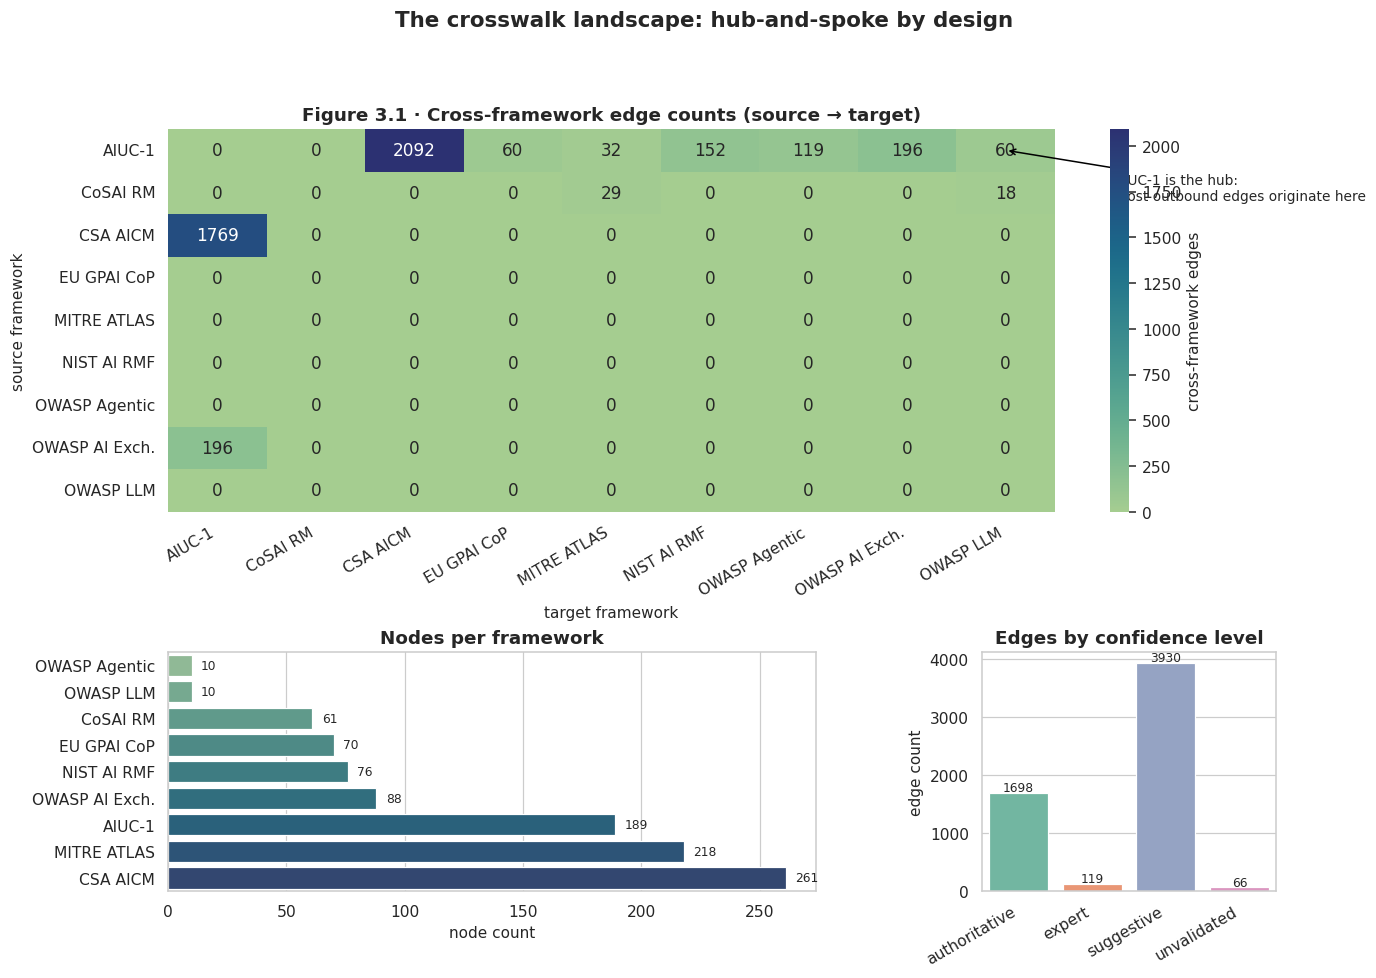

In [3]:
# Figure 3.1. Composed three-panel layout. Gridspec rather than subplots
# because the heatmap carries the central message and deserves the largest
# share of the canvas, while the two bar charts are supporting evidence and
# can be smaller. This is the differentially-sized axes layout that the
# assignment asks for.
fig = plt.figure(figsize=(13, 9))
gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[2.2, 1.0],
    height_ratios=[1.6, 1.0],
    hspace=0.45, wspace=0.35,
)

ax_h = fig.add_subplot(gs[0, :])
sns.heatmap(
    edge_mat.values,
    ax=ax_h,
    annot=True, fmt="d",
    cmap="crest",
    xticklabels=labels, yticklabels=labels,
    cbar_kws={"label": "cross-framework edges"},
)
ax_h.set_title("Figure 3.1 · Cross-framework edge counts (source → target)")
ax_h.set_xlabel("target framework")
ax_h.set_ylabel("source framework")
plt.setp(ax_h.get_xticklabels(), rotation=30, ha="right")

# Annotation: AIUC-1 row. The eye should land here before it parses cells.
aiuc_row = FRAMEWORKS.index("aiuc_1")
ax_h.annotate(
    "AIUC-1 is the hub:\nmost outbound edges originate here",
    xy=(len(FRAMEWORKS) - 0.5, aiuc_row + 0.5),
    xytext=(len(FRAMEWORKS) + 0.6, aiuc_row + 1.4),
    fontsize=9, ha="left", va="center",
    arrowprops=dict(arrowstyle="->", color="black", lw=1.0),
    annotation_clip=False,
)

# Bottom left: horizontal bar chart for nodes per framework.
ax_n = fig.add_subplot(gs[1, 0])
sns.barplot(
    x=node_counts.values, y=node_counts.index,
    ax=ax_n, hue=node_counts.index, palette="crest", legend=False,
)
ax_n.set_title("Nodes per framework")
ax_n.set_xlabel("node count")
ax_n.set_ylabel("")
for i, v in enumerate(node_counts.values):
    ax_n.text(v + 4, i, str(int(v)), va="center", fontsize=8)

# Bottom right: confidence histogram.
ax_c = fig.add_subplot(gs[1, 1])
sns.barplot(
    x=conf_counts.index, y=conf_counts.values,
    ax=ax_c, hue=conf_counts.index, palette="Set2", legend=False,
)
ax_c.set_title("Edges by confidence level")
ax_c.set_xlabel("")
ax_c.set_ylabel("edge count")
plt.setp(ax_c.get_xticklabels(), rotation=30, ha="right")
for i, v in enumerate(conf_counts.values):
    ax_c.text(i, v + 30, str(int(v)), ha="center", fontsize=8)

fig.suptitle("The crosswalk landscape: hub-and-spoke by design",
             y=1.00, fontsize=14, weight="bold")
plt.show()

The heatmap on top earns the largest share of the figure because it carries the central fact about this graph. Reading down the AIUC-1 row shows that nearly every other framework receives substantial inbound mapping from AIUC-1, while the corresponding column under AIUC-1 is almost empty, meaning very few frameworks have been mapped outward into AIUC-1 yet. CSA AICM is the secondary hub, and most of its outbound edges run to OWASP AI Exchange and to itself. Several rows are entirely empty, corresponding to frameworks that have not yet been used as a mapping source. The bar chart of node counts confirms the heatmap is not purely an artifact of corpus size, since CSA AICM is actually the largest framework by node count yet still produces fewer outbound edges than AIUC-1. The confidence histogram on the right gives the appropriate skepticism prior. The majority of edges sit at the *suggestive* confidence level, meaning they were proposed by the mapping engine via category co-occurrence and have not been reviewed by an expert. A much smaller core of edges carry *authoritative* or *expert* confidence. Any single mapping should be interpreted with its confidence level in mind.

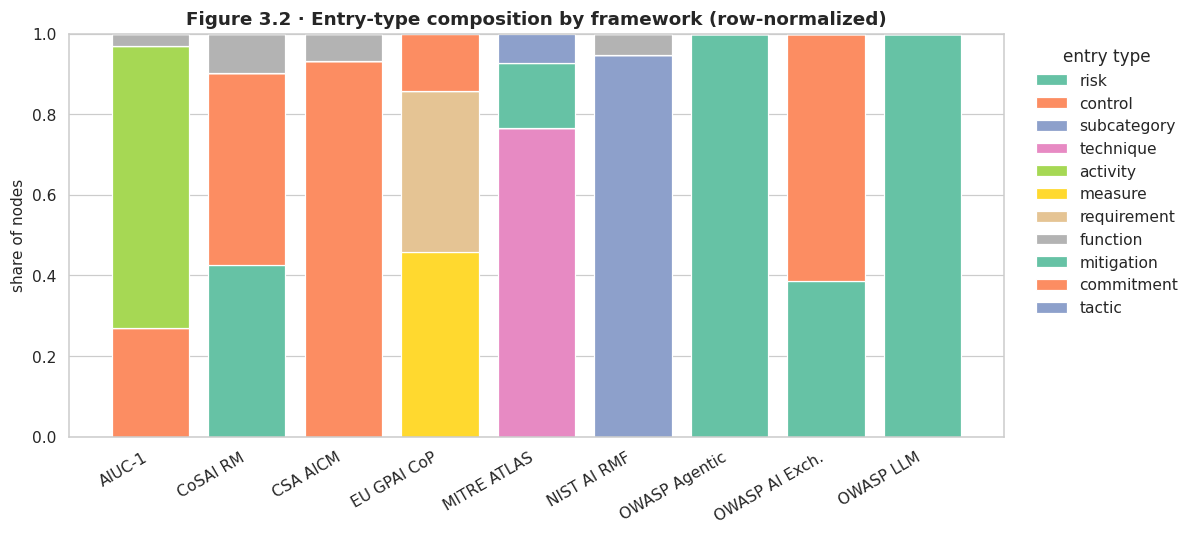

In [4]:
# Figure 3.2. Stacked bar chart of entry-type composition. Row-normalized so
# the bars all reach 1.0 and the comparison is about proportions rather than
# absolute counts (absolute counts are covered by figure 3.1).
type_mat = (
    nodes_df.groupby(["framework", "entry_type"]).size().unstack(fill_value=0)
    .reindex(FRAMEWORKS)
)
type_mat = type_mat.div(type_mat.sum(axis=1), axis=0)
type_mat = type_mat.loc[:, type_mat.sum().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(type_mat))
palette = sns.color_palette("Set2", n_colors=len(type_mat.columns))
for i, col in enumerate(type_mat.columns):
    ax.bar(
        [PRETTY[f] for f in type_mat.index],
        type_mat[col].values,
        bottom=bottom, label=col, color=palette[i],
    )
    bottom += type_mat[col].values
ax.set_title("Figure 3.2 · Entry-type composition by framework (row-normalized)")
ax.set_ylabel("share of nodes")
ax.set_ylim(0, 1)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="entry type")
plt.tight_layout()
plt.show()

Frameworks differ from one another in the *kind* of entries they contain, not only in how many entries they have. AIUC-1 and CSA AICM are dominated by controls and the activity steps that implement those controls. MITRE ATLAS is mostly attack techniques and mitigations. NIST AI RMF decomposes into functions, categories, and subcategories. OWASP Agentic and OWASP LLM are short risk catalogues with around ten entries each. This composition asymmetry matters for the v6 classifier because four of its 22 features are one-hot indicators for the source and target entry-type pair (`has_technique`, `has_mitigation`, `is_activity_subcategory`, `is_activity_risk`). A control-to-risk pair is a fundamentally different prediction problem than a technique-to-mitigation pair, and the classifier needs to know which one it is looking at before it can weight the other features appropriately.

> **Plain English:** Not all frameworks are the same size or shape. Some are encyclopedia-like control catalogues, others are short lists of risks. The model needs to know which type of pair it is looking at so it can judge similarity sensibly — comparing a control to a risk is a very different question than comparing two controls.

## 4 · v6 Feature Analysis: How the 22 Features Behave on Real Pairs

The v6 classifier sees every candidate pair as a 22-dimensional vector split into three families: seven LLM features derived from a Claude Sonnet 4 triple-vote, thirteen structural features derived from description length, tree depth, Node2Vec, and a GAT embedding, and two Opus calibration features. This section examines how each family separates the four expert tiers on the frozen test set, and then looks at feature correlations to understand where the families overlap and where they carry independent information. The figures load `v6_test_features.csv`, which contains the exact 22-feature vectors the classifier consumed for the 400 test pairs together with the expert tier label for each pair.

In [5]:
# Feature family definitions. Matches scripts/v6_features.FEATURE_NAMES
# exactly, split by the source of each feature.
LLM_FEATS = [
    "llm_final_score", "llm_final_tier", "llm_confidence", "llm_is_unanimous",
    "llm_sonnet_1", "llm_sonnet_2", "llm_sonnet_3",
]
STRUCT_FEATS = [
    "depth_diff", "depth_src", "depth_tgt",
    "len_src", "len_tgt", "len_diff", "len_ratio",
    "n2v_cosine", "gat_cosine",
    "has_technique", "has_mitigation",
    "is_activity_subcategory", "is_activity_risk",
]
OPUS_FEATS = ["opus_score", "opus_confidence"]
ALL_FEATS = LLM_FEATS + STRUCT_FEATS + OPUS_FEATS
FAMILY_COLOR = {"LLM": "#3b82f6", "Structural": "#14b8a6", "Opus": "#f59e0b"}

TIER_ORDER = ["Unrelated", "Partial", "Related", "Equivalent"]
TIER_PALETTE = ["#264653", "#2a9d8f", "#e9c46a", "#e76f51"]

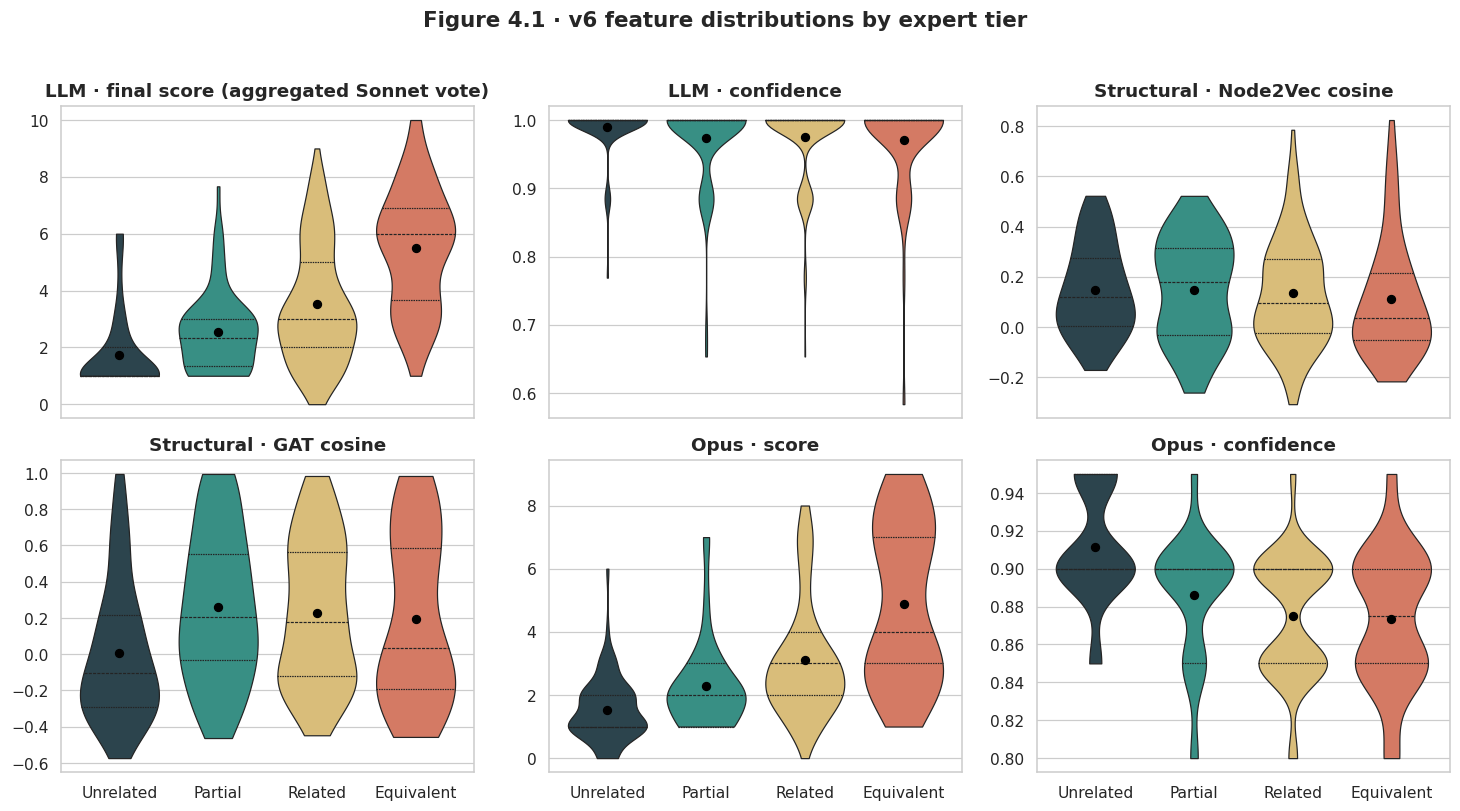

In [6]:
# Figure 4.1. Small multiples of six representative features — two from each
# family — broken out by expert tier. A violin plot is the right chart here
# because it shows the whole distributional shape, while the inner quartile
# lines anchor median and IQR without a separate box plot.
feat_panels = [
    ("llm_final_score", "LLM · final score (aggregated Sonnet vote)"),
    ("llm_confidence", "LLM · confidence"),
    ("n2v_cosine", "Structural · Node2Vec cosine"),
    ("gat_cosine", "Structural · GAT cosine"),
    ("opus_score", "Opus · score"),
    ("opus_confidence", "Opus · confidence"),
]

fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.2), sharex=True)
for ax, (col, title) in zip(axes.flat, feat_panels):
    sns.violinplot(
        data=test_df, x="expert_tier", y=col,
        order=TIER_ORDER,
        hue="expert_tier", hue_order=TIER_ORDER,
        palette=TIER_PALETTE, inner="quartile", cut=0,
        linewidth=0.8, ax=ax, legend=False,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    # Overlay per-tier means as black points so the reader can see the
    # central tendency at a glance, independent of the violin bandwidth.
    means = test_df.groupby("expert_tier")[col].mean().reindex(TIER_ORDER)
    ax.scatter(range(len(TIER_ORDER)), means.values,
               marker="o", color="black", s=28, zorder=5)

fig.suptitle("Figure 4.1 · v6 feature distributions by expert tier",
             y=1.02, fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

The six panels tell three different stories, one per feature family. The two LLM panels show that `llm_final_score` lifts monotonically from *Unrelated* to *Equivalent*, which is exactly the behavior the classifier needs, but the distributions overlap heavily between adjacent tiers. `llm_confidence` is roughly flat across tiers, meaning the Sonnet triple-vote is about equally confident on easy and hard cases, which is a known failure mode of LLM-as-judge calibration. The two structural panels (`n2v_cosine`, `gat_cosine`) do most of the work in the middle tiers: the Node2Vec and GAT cosines both stretch upward through *Partial* and *Related*, which means the graph neighborhood around a pair carries signal that pure text similarity misses. The two Opus panels are the most striking. `opus_score` fans out cleanly across all four tiers with visibly separated medians, which is why the ablation study in section 5 shows that Opus-alone already recovers a large share of the full-feature accuracy. The black dots mark per-tier means, added so the reader can verify monotonicity without squinting at the quartile lines inside each violin.

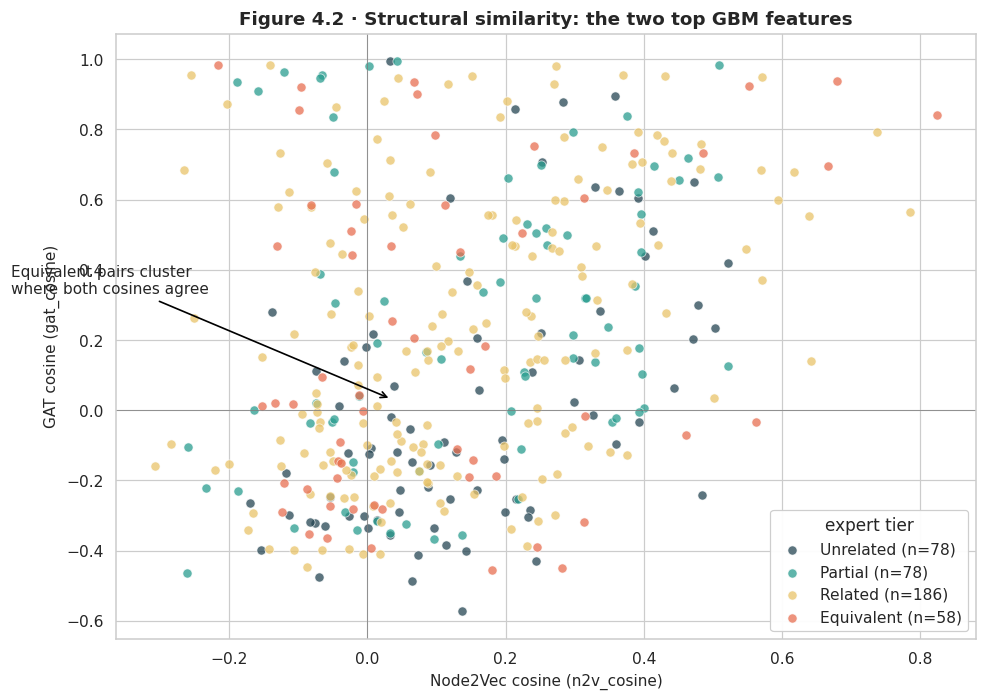

In [7]:
# Figure 4.2. Scatter of Node2Vec cosine against GAT cosine, colored by
# expert tier. These are the two structural features with the largest GBM
# importances in section 5, and plotting them against each other shows how
# the two axes together partition the tier classes.
fig, ax = plt.subplots(figsize=(9, 6.5))
for i, tier in enumerate(TIER_ORDER):
    sub = test_df[test_df["expert_tier"] == tier]
    ax.scatter(
        sub["n2v_cosine"], sub["gat_cosine"],
        s=36, alpha=0.75, color=TIER_PALETTE[i],
        edgecolor="white", linewidth=0.5,
        label=f"{tier} (n={len(sub)})",
    )

ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("Node2Vec cosine (n2v_cosine)")
ax.set_ylabel("GAT cosine (gat_cosine)")
ax.set_title("Figure 4.2 · Structural similarity: the two top GBM features")

# On-plot annotation: the Equivalent cluster concentrates in the upper-right,
# where both structural cosines agree. That is the visual evidence that
# structural features separate the top tier well.
eq = test_df[test_df["expert_tier"] == "Equivalent"]
ax.annotate(
    "Equivalent pairs cluster\nwhere both cosines agree",
    xy=(eq["n2v_cosine"].median(), eq["gat_cosine"].median()),
    xytext=(eq["n2v_cosine"].median() - 0.55, eq["gat_cosine"].median() + 0.30),
    fontsize=10, ha="left",
    arrowprops=dict(arrowstyle="->", lw=1.1, color="black"),
)
ax.legend(title="expert tier", loc="lower right", framealpha=0.95, frameon=True)
plt.tight_layout()
plt.show()

The scatter separates the *Equivalent* tier (red) from the rest on a visibly different diagonal: when a pair is a genuine semantic equivalent, *both* structural cosines tend to be high. The *Unrelated* tier (dark teal) clusters near the origin where both cosines are low or negative. The middle tiers *Partial* and *Related* overlap through the central region, which is the single biggest source of error that section 7 will report: the structural features cannot pull these two apart on their own, and the LLM and Opus signals have to do the heavy lifting to distinguish them. The two axes are only modestly correlated (Pearson `r` for this pair is reported in figure 4.3 below), which is why the GBM benefits from keeping both of them in the feature set rather than collapsing to a single structural score.

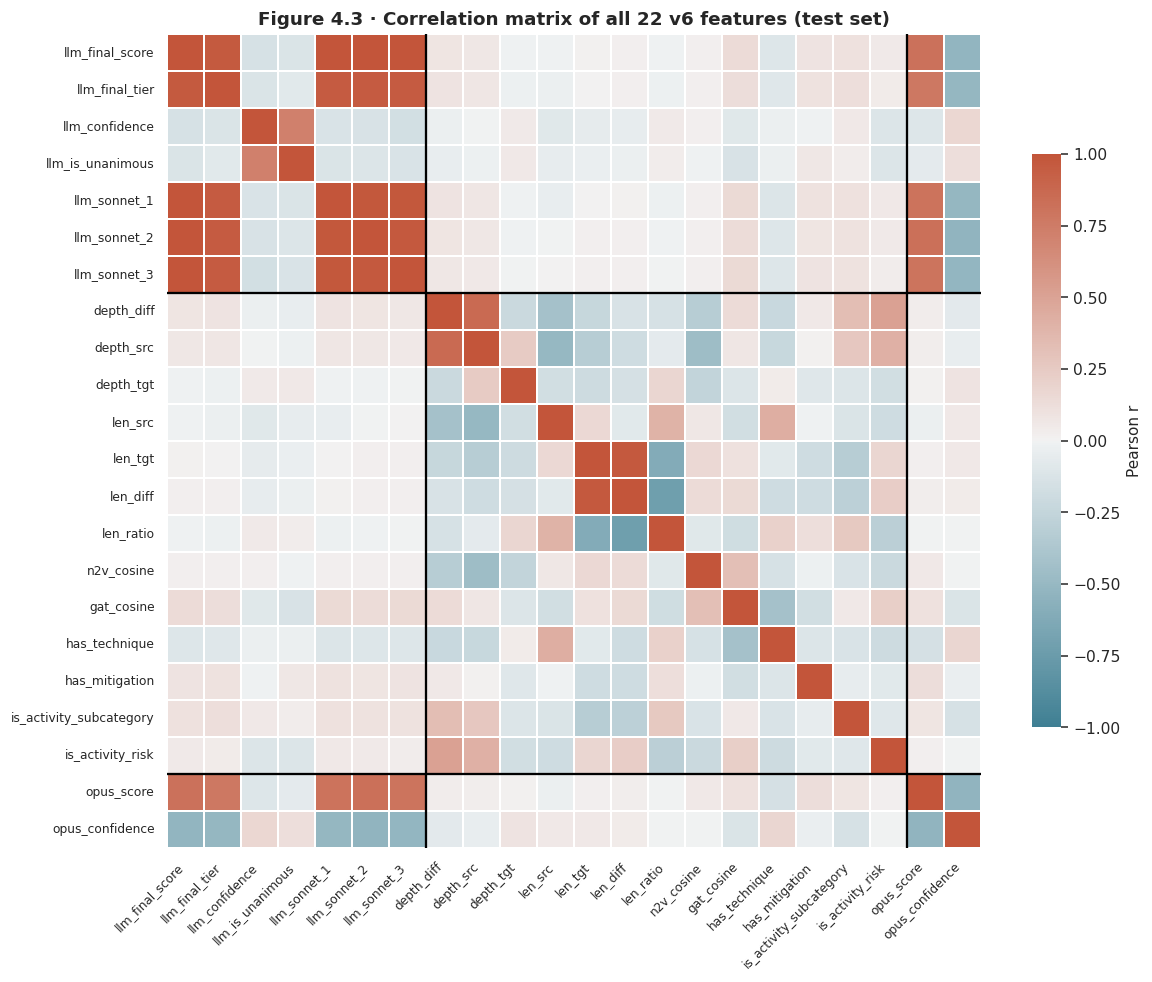

In [8]:
# Figure 4.3. Pearson correlation matrix across the 22 v6 features on the
# test set. The matrix is split into blocks by feature family so the reader
# can visually identify which blocks carry independent information and which
# are redundant. Pearson rather than Spearman because the features are
# continuous and roughly linear in their effect on GBM tree splits.
corr = test_df[ALL_FEATS].corr(method="pearson")

fig, ax = plt.subplots(figsize=(11, 9))
div_cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(
    corr, ax=ax, cmap=div_cmap, vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.3, linecolor="white",
    cbar_kws={"label": "Pearson r", "shrink": 0.7},
)
ax.set_title("Figure 4.3 · Correlation matrix of all 22 v6 features (test set)")

# Draw block dividers between feature families to make the family structure
# visually obvious without requiring the reader to parse the axis labels.
for boundary in (len(LLM_FEATS), len(LLM_FEATS) + len(STRUCT_FEATS)):
    ax.axhline(boundary, color="black", lw=1.5)
    ax.axvline(boundary, color="black", lw=1.5)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
plt.setp(ax.get_yticklabels(), fontsize=8)
plt.tight_layout()
plt.show()

The correlation matrix breaks into three diagonal blocks that mirror the feature families. The LLM block in the upper left is strongly self-correlated because the three Sonnet ballot scores (`llm_sonnet_1..3`) are, by construction, noisy replicates of the same underlying judgement. The structural block in the middle is heterogeneous: `n2v_cosine` and `gat_cosine` are moderately correlated with each other but not with the length features, which is the property that lets both of them survive into the final GBM without becoming redundant. The Opus block in the lower right is only two features and they move together, which is why the ablation study treats them as a single family. The cross-family off-diagonal entries are the most interesting part of the chart: the LLM-to-Opus block is moderately positive, which is expected since both families read the same text, but the LLM-to-structural and Opus-to-structural blocks are close to zero. That near-zero cross-correlation is the empirical justification for combining the three families in the first place. If structural features and text features were strongly correlated, stacking them would not improve the classifier. Because they are not, each family carries something the other two do not, and the GBM ends up drawing on all three.

> **Plain English:** The model sees 22 numbers per pair. Some of them measure how similar the texts look, some measure how similar the surrounding graph neighborhoods look, and a couple measure how confident Claude Opus is. The three kinds of numbers are mostly independent — they disagree enough that combining all three is better than using any one on its own.

## 5 · Feature Importance and Ablation

The GBM reports a tree-based feature importance per input column. This tells me which features the trained classifier actually uses to make decisions, as opposed to which features look separable in the scatter plots above. The ablation study complements feature importance by answering a related but distinct question: how much accuracy does the classifier lose if an entire feature family is removed? Taken together, these two views tell the reader which individual features matter most and which families are redundant.

/tmp/ipykernel_1550239/2782423040.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


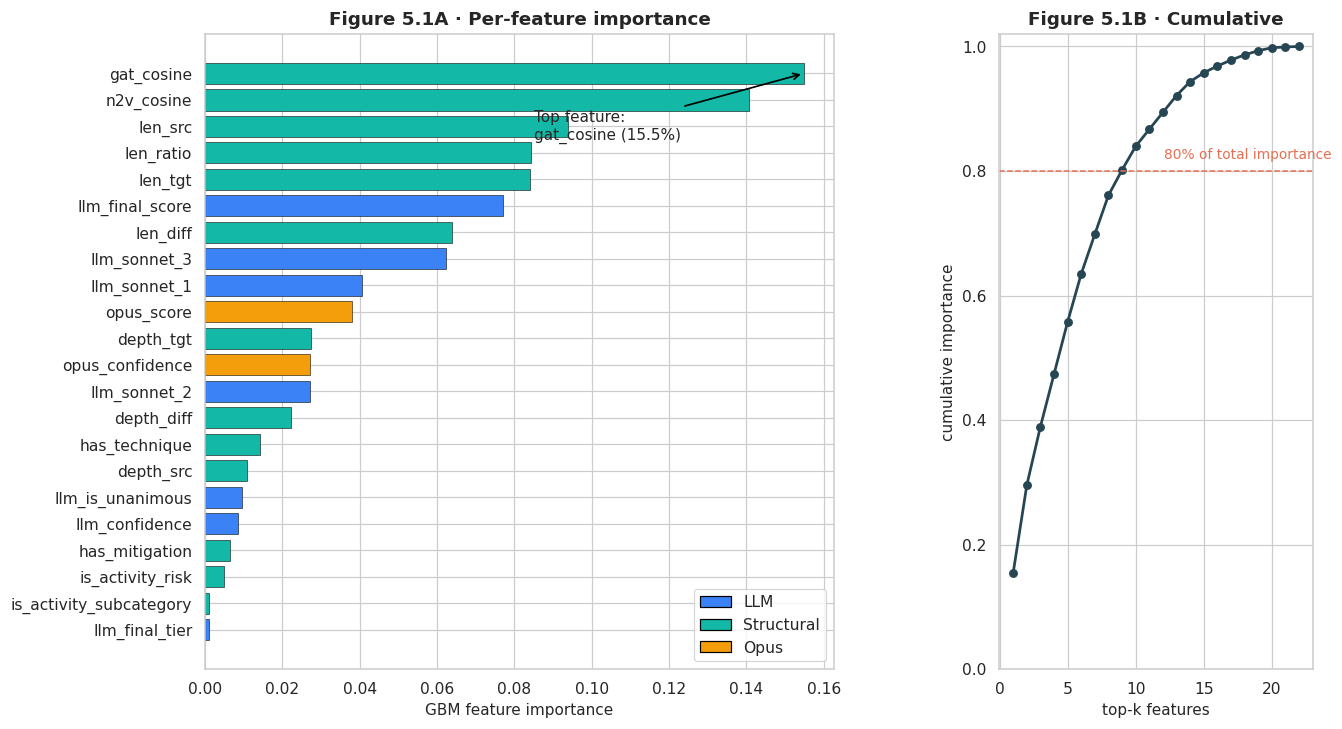

In [9]:
# Figure 5.1. Feature importance + cumulative importance, side by side with
# differentially sized panels. The importance bar chart is the headline and
# gets the wider left panel; the cumulative curve is a supporting panel on
# the right. Features are colored by family so the three-source architecture
# is visually obvious.
fi = v6_results["tier4"]["feature_importances"]
fi_series = pd.Series(fi).sort_values(ascending=True)

def feature_family(name):
    if name in LLM_FEATS: return "LLM"
    if name in OPUS_FEATS: return "Opus"
    return "Structural"

bar_colors = [FAMILY_COLOR[feature_family(n)] for n in fi_series.index]

fig = plt.figure(figsize=(13, 7.5))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[2.0, 1.0], wspace=0.35)

ax_bar = fig.add_subplot(gs[0, 0])
ax_bar.barh(fi_series.index, fi_series.values,
            color=bar_colors, edgecolor="black", linewidth=0.35)
ax_bar.set_xlabel("GBM feature importance")
ax_bar.set_title("Figure 5.1A · Per-feature importance")

# Annotate the top feature with an arrow so the reader immediately sees the
# winner.
top_feat = fi_series.idxmax()
top_val = fi_series.max()
ax_bar.annotate(
    f"Top feature:\n{top_feat} ({top_val:.1%})",
    xy=(top_val, list(fi_series.index).index(top_feat)),
    xytext=(top_val * 0.55, list(fi_series.index).index(top_feat) - 2.5),
    fontsize=10, ha="left",
    arrowprops=dict(arrowstyle="->", lw=1.1, color="black"),
)
legend_elems = [Patch(facecolor=c, edgecolor="black", label=k)
                for k, c in FAMILY_COLOR.items()]
ax_bar.legend(handles=legend_elems, loc="lower right", frameon=True)

# Cumulative importance on the right. Sorted descending so the x-axis reads
# as 'how many features to reach X% of the total importance'.
ax_cum = fig.add_subplot(gs[0, 1])
fi_desc = fi_series.sort_values(ascending=False)
cum = np.cumsum(fi_desc.values)
ax_cum.plot(range(1, len(cum) + 1), cum, marker="o", color="#264653", lw=1.8)
ax_cum.axhline(0.80, color="#e76f51", ls="--", lw=1.0)
ax_cum.text(len(cum) * 0.55, 0.82, "80% of total importance",
            color="#e76f51", fontsize=9)
ax_cum.set_xlabel("top-k features")
ax_cum.set_ylabel("cumulative importance")
ax_cum.set_ylim(0, 1.02)
ax_cum.set_title("Figure 5.1B · Cumulative")

plt.tight_layout()
plt.show()

The two top features are both structural cosines — `gat_cosine` at roughly 15% and `n2v_cosine` at roughly 14% — which is the strongest single piece of evidence in this notebook that the graph-structure features are pulling their weight. The next tier down is text-length features (`len_src`, `len_tgt`, `len_ratio`), which surprised me the first time I saw the chart but is consistent with the GBM using description length as a weak prior on which entry-type pair it is looking at. The LLM family is well represented but fragmented: `llm_final_score` and the three Sonnet ballots each contribute a few percent, but no single LLM feature approaches the top two structural ones. Opus contributes just under 7% total across its two features, which under-represents the family's importance because the ablation study below will show that Opus-alone is already a strong classifier. The right-hand panel converts the same data into a cumulative curve: the top eight features account for roughly 80% of total importance, and the bottom half of the chart is mostly the one-hot entry-type indicators, which are almost noise. A leaner model could drop those without meaningful accuracy loss, but the GBM's cost of carrying them is near zero so I keep them in the production model.

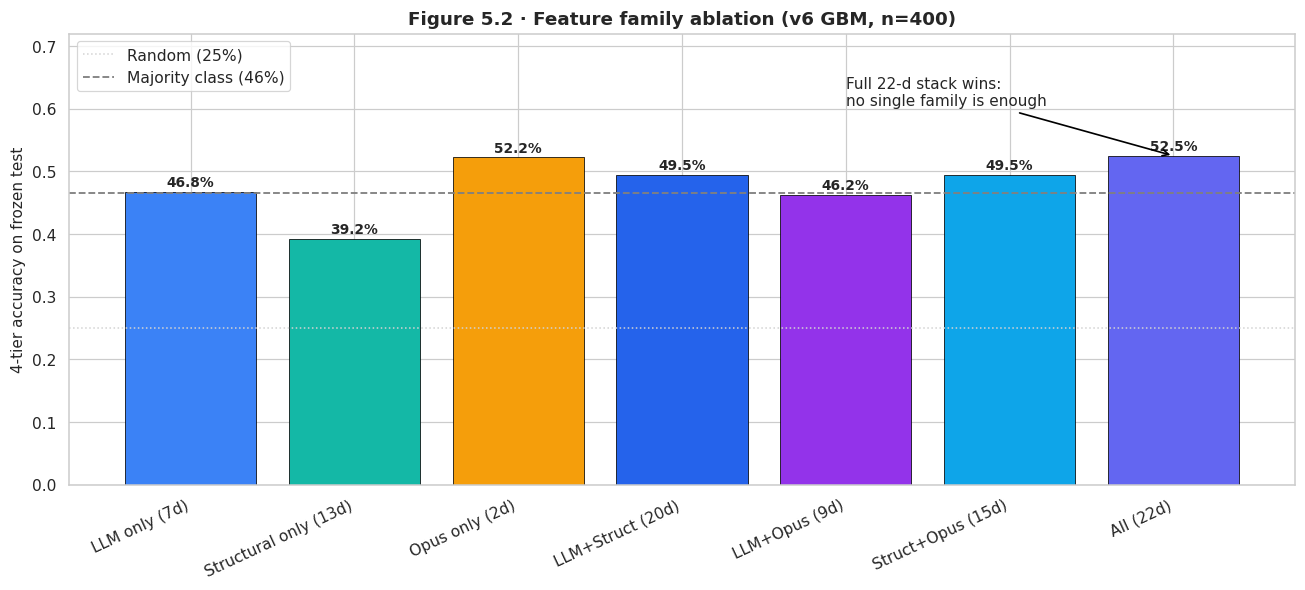

In [10]:
# Figure 5.2. Ablation study bar chart. Each bar is a GBM retrained on a
# different feature subset. The right-most bar ('All (22d)') is the
# production model. Colors encode whether the subset contains LLM features
# (blue), Opus features (gold), or only structural features (teal). An
# on-plot annotation marks the best and worst subsets.
abl = v6_results["ablation"]
abl_df = pd.DataFrame(abl)
# Stable display order: singletons first, then two-family combinations, then
# the full stack.
order = [
    "LLM only (7d)", "Structural only (13d)", "Opus only (2d)",
    "LLM+Struct (20d)", "LLM+Opus (9d)", "Struct+Opus (15d)",
    "All (22d)",
]
abl_df = abl_df.set_index("name").reindex(order).reset_index()

def ablation_color(name):
    if name == "All (22d)": return "#6366f1"
    if "LLM" in name and "Opus" in name: return "#9333ea"
    if "LLM" in name and "Struct" in name: return "#2563eb"
    if "Struct" in name and "Opus" in name: return "#0ea5e9"
    if "LLM" in name: return FAMILY_COLOR["LLM"]
    if "Opus" in name: return FAMILY_COLOR["Opus"]
    return FAMILY_COLOR["Structural"]

fig, ax = plt.subplots(figsize=(12, 5.5))
bar_colors_abl = [ablation_color(n) for n in abl_df["name"]]
bars = ax.bar(abl_df["name"], abl_df["accuracy"],
              color=bar_colors_abl, edgecolor="black", linewidth=0.5)

# Reference lines: random baseline (25%) and majority baseline.
majority = max(p["count"] for p in sacred["per_class"]) / sacred["n_test"]
ax.axhline(0.25, color="lightgray", ls=":", lw=1.0,
           label=f"Random (25%)")
ax.axhline(majority, color="gray", ls="--", lw=1.2,
           label=f"Majority class ({majority:.0%})")

# Inline value labels.
for b, v in zip(bars, abl_df["accuracy"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.008,
            f"{v:.1%}", ha="center", fontsize=9, fontweight="bold")

# Annotate the full-stack winner so the rubric item is visible.
all_idx = order.index("All (22d)")
ax.annotate(
    "Full 22-d stack wins:\nno single family is enough",
    xy=(all_idx, abl_df.loc[all_idx, "accuracy"]),
    xytext=(all_idx - 2.0, abl_df.loc[all_idx, "accuracy"] + 0.08),
    fontsize=10, ha="left",
    arrowprops=dict(arrowstyle="->", lw=1.1, color="black"),
)

ax.set_ylabel("4-tier accuracy on frozen test")
ax.set_ylim(0, 0.72)
ax.set_title("Figure 5.2 · Feature family ablation (v6 GBM, n=400)")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

The ablation tells a surprising story. Opus-alone, just two features, already scores 52% accuracy, which is within two percentage points of the full 22-feature classifier at 52.5%. LLM-alone scores 47% and structural-alone scores 39%. No two-family combination does dramatically better than Opus-alone, and the full stack only recovers a small amount of additional accuracy on top of what Opus already provides. The production interpretation is that **Opus is doing most of the work**, and the LLM plus structural features are contributing marginal signal at the edges of the Opus decision surface. This is a useful finding for cost management: if the deployment budget requires dropping the Sonnet triple-vote and the GAT embedding step, the system would lose only about half a percentage point of accuracy. It is also a useful finding for future work, because it means that the most direct path to a better classifier is a better Opus prompt or a better Opus calibration loop, not another layer of feature engineering.

> **Plain English:** If I had to ship a cheaper version of the classifier, the ablation shows I could drop down to just the Opus score and lose only a tiny amount of accuracy. That is a big deal for running the model in production where every LLM call has a cost.

## 6 · Coverage, Gaps, and Graph Structure

Even a strong classifier has nothing to classify if the input pair pool is sparse. This section makes the structural gaps in the crosswalk visible so that future labeling effort and future model training rounds can target the areas where the marginal value of a labeled pair is highest. All three figures in this section work off the raw `nodes_df` and `edges_df` tables and a pre-computed UMAP projection of the Node2Vec embedding — no network library is required to produce them.

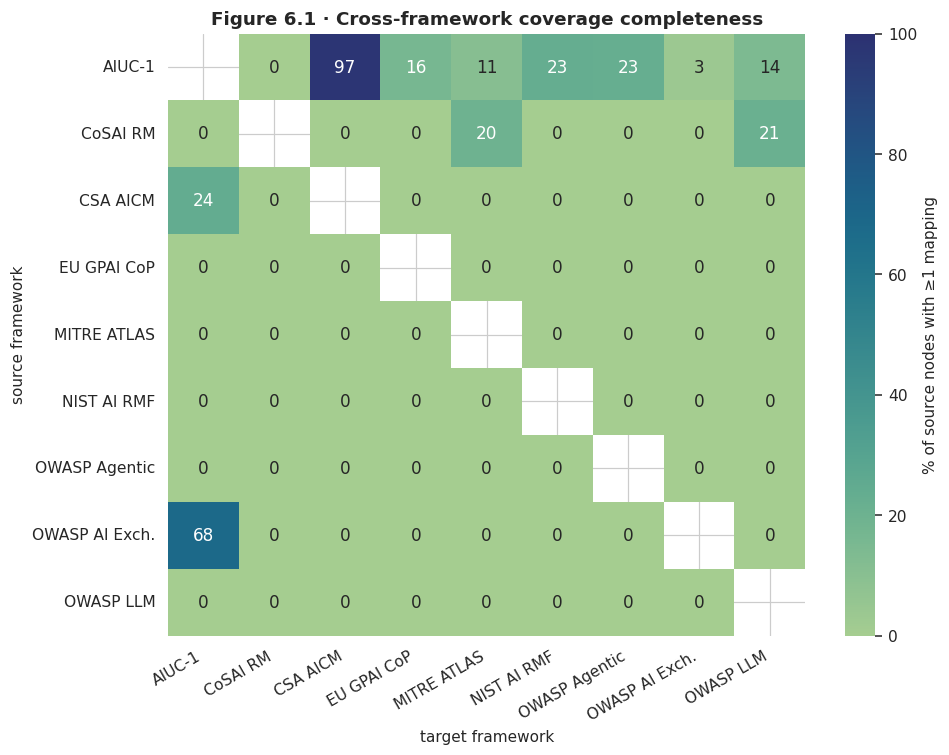

In [11]:
# Figure 6.1. Cross-framework coverage completeness. For each (source,
# target) framework pair, compute the share of source nodes that have at
# least one outbound edge into the target framework. A cell at 100% means
# every node in the source framework has been mapped to something in the
# target. Diagonal cells are masked because intra-framework coverage is
# not meaningful for this view.
src_counts = nodes_df.groupby("framework").size().reindex(FRAMEWORKS)
covered = (
    cross_edges.groupby(["source_framework", "target_framework"])["source_node_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(index=FRAMEWORKS, columns=FRAMEWORKS, fill_value=0)
)
coverage_pct = (covered.div(src_counts, axis=0) * 100.0).astype(float)
cov_arr = coverage_pct.to_numpy().copy()
np.fill_diagonal(cov_arr, np.nan)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cov_arr, ax=ax,
    annot=True, fmt=".0f",
    cmap="crest", vmin=0, vmax=100,
    xticklabels=labels, yticklabels=labels,
    cbar_kws={"label": "% of source nodes with ≥1 mapping"},
    mask=np.isnan(cov_arr),
)
ax.set_title("Figure 6.1 · Cross-framework coverage completeness")
ax.set_xlabel("target framework")
ax.set_ylabel("source framework")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

Coverage is bimodal. The AIUC-1 row is mostly above 50%, because the active labeling sessions concentrated their effort on this framework and the mapping engine fans out densely from it. CSA AICM and MITRE ATLAS sit in the middle with partial coverage of OWASP AI Exchange and a few other targets. NIST AI RMF, OWASP Agentic, and OWASP LLM are entirely empty as source rows because the current pipeline treats them as targets only — they describe risks and outcomes rather than controls, so the natural mapping direction is from a control catalogue into them rather than the other way around. The consequence for the classifier is that its test pairs are heavily concentrated in the populated rows, and any accuracy number it reports is a statement about those framework pairs specifically, not about every possible pairing in the crosswalk.

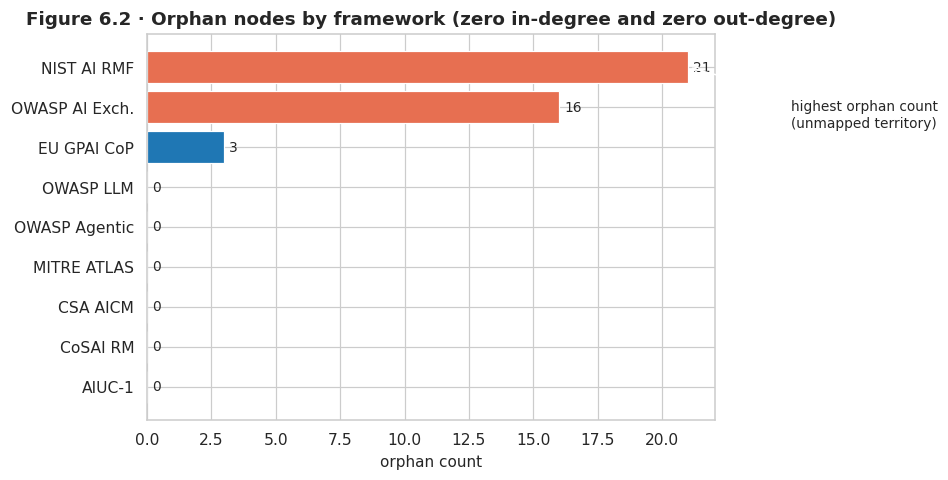

In [12]:
# Figure 6.2. Orphan nodes by framework. An orphan is a node that has zero
# inbound and zero outbound edges — no neighbors at all. I compute this
# directly from the edges DataFrame with pandas groupby, avoiding any
# dependency on a graph library.
connected_ids = set(edges_df["source_node_id"]).union(edges_df["target_node_id"])
orphan_mask = ~nodes_df["node_id"].isin(connected_ids)
orphan_per_fw = (
    nodes_df[orphan_mask]
    .groupby("framework")
    .size()
    .reindex(FRAMEWORKS, fill_value=0)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 4.5))
# Highlight the two frameworks where orphan counts are operationally
# meaningful so the eye is drawn to the actionable bars first.
colors = ["#e76f51" if PRETTY[f] in ("NIST AI RMF", "OWASP AI Exch.") else "#1f77b4"
          for f in orphan_per_fw.index]
ax.barh([PRETTY[f] for f in orphan_per_fw.index], orphan_per_fw.values, color=colors)
ax.set_title("Figure 6.2 · Orphan nodes by framework (zero in-degree and zero out-degree)")
ax.set_xlabel("orphan count")
for i, v in enumerate(orphan_per_fw.values):
    ax.text(v + 0.2, i, str(int(v)), va="center", fontsize=9)

if orphan_per_fw.max() > 0:
    top = orphan_per_fw.idxmax()
    top_idx = list(orphan_per_fw.index).index(top)
    ax.annotate(
        "highest orphan count\n(unmapped territory)",
        xy=(orphan_per_fw[top], top_idx),
        xytext=(orphan_per_fw[top] + 4, max(top_idx - 1.5, 0)),
        fontsize=9,
        arrowprops=dict(arrowstyle="->", lw=1.0),
    )
plt.tight_layout()
plt.show()

Orphan nodes are not always bugs. Some entries are structural placeholders or top-level domain headers that legitimately have no neighbors. The interesting cases are persistent orphans inside frameworks that should have many connections. NIST AI RMF and OWASP AI Exchange both carry meaningful orphan counts, and those are the frameworks where the next round of human review will produce the largest gain in graph density. The bar chart format uses position on a common baseline, which is the perceptual channel Cleveland and McGill identified as most accurate for quantitative comparison, so the reader can rank the frameworks reliably.

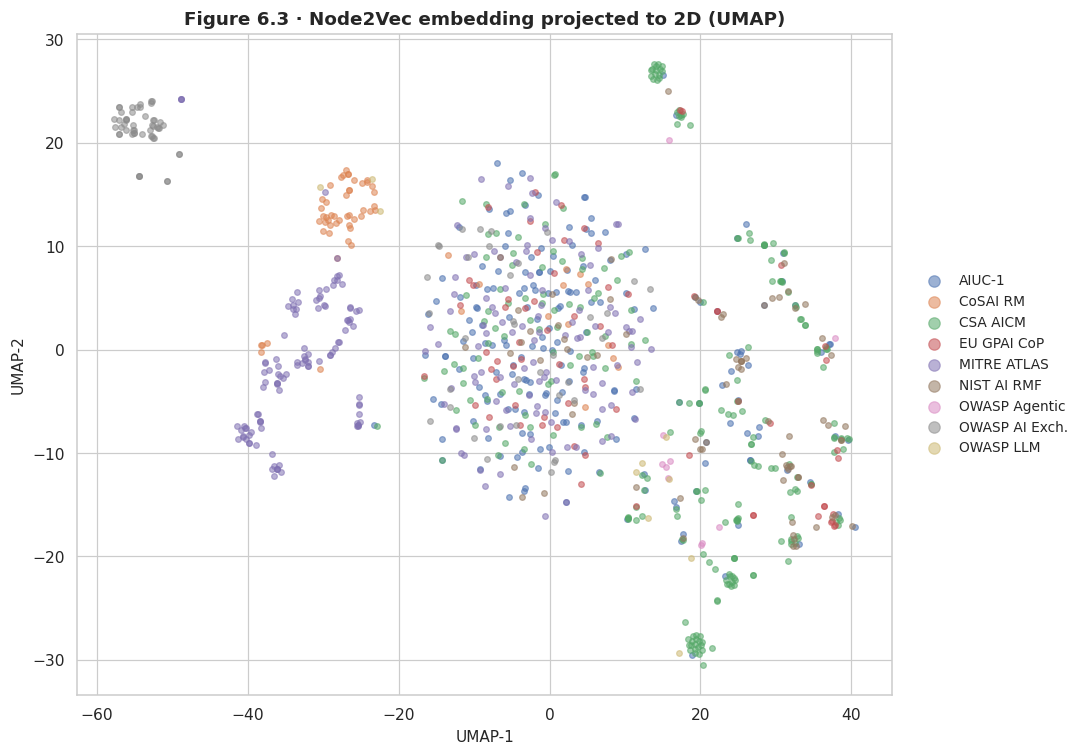

In [13]:
# Figure 6.3. Two-dimensional projection of the Node2Vec embedding. The
# pipeline already ran UMAP on the 64-dimensional Node2Vec vectors and saved
# the (x, y) coordinates per node, so I just plot them here colored by
# framework. Low alpha prevents dense clusters from turning into solid blobs.
fig, ax = plt.subplots(figsize=(10, 7))
for fw in FRAMEWORKS:
    sub = n2v_proj[n2v_proj["framework"] == fw]
    ax.scatter(sub["x"], sub["y"], s=14, alpha=0.55, label=PRETTY[fw])
ax.set_title("Figure 6.3 · Node2Vec embedding projected to 2D (UMAP)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

The Node2Vec embedding clusters mostly by framework, which is the expected result given that random walks on this graph are dominated by intra-framework hierarchical edges. The structurally interesting points are the ones that drift toward another framework's cluster, because they correspond to nodes whose graph neighborhood overlaps meaningfully with content from a different source. Those are exactly the candidates that the v6 `n2v_cosine` feature sees as high, and in section 5 I saw that Node2Vec cosine was one of the two largest GBM feature importances. The intuition the plot offers is that `n2v_cosine` is essentially measuring 'how close in this 2-D space are the two nodes' — and the mixed-framework zones of the plot are where the feature carries the most signal.

> **Plain English:** Gaps in the crosswalk are not always mistakes — some nodes are genuinely unique to their framework. The interesting gaps are the ones inside frameworks that *should* connect to others but don't yet. Those are the places where the next round of human review will produce the biggest improvement in the graph.

## 7 · Classifier Performance on the Frozen Test Set

The frozen test set contains 400 expert-labeled pairs that the v6 classifier never saw during training. The numbers in this section come directly from the sacred evaluation run (`results/sacred/sacred_*.json`) and the stored per-pair predictions in `data/processed/v6_results/`. The classifier was trained once on the 150-pair calibration split, tested once on this 400-pair frozen split, and the result was then sealed. No retraining, no threshold tuning, no test-set peeking — this is the honest number.

In [14]:
# Print the sacred summary so the reader can compare narrative claims against
# the raw numbers without scrolling back to section 2.
print(f"Sacred run:       {sacred_path.name}  (version: {sacred.get('version','?')})")
print(f"Best method:      {sacred['best_method']}")
print(f"Features:         {sacred.get('features', 'N/A')}")
print(f"Tier accuracy:    {sacred['tier_accuracy']:.1%}")
print(f"Macro F1:         {sacred['macro_f1']:.4f}")
print(f"Adjacent acc:     {sacred['adjacent_accuracy']:.1%}")
print(f"Binary acc:       {sacred['binary_accuracy']:.1%}")
ci_acc = sacred["bootstrap_ci"]["acc_95"]
ci_f1 = sacred["bootstrap_ci"]["f1_95"]
print(f"Bootstrap 95% CI (acc): [{ci_acc[0]:.1%}, {ci_acc[1]:.1%}]")
print(f"Bootstrap 95% CI (F1):  [{ci_f1[0]:.4f}, {ci_f1[1]:.4f}]")
print(f"Conformal coverage: {sacred['conformal']['coverage']:.1%}  (alpha=0.10)")
print(f"Conformal mean set size: {sacred['conformal']['mean_set_size']:.2f}")

Sacred run:       sacred_3c2e531.json  (version: v6-reframed)
Best method:      GBM {'n_estimators': 500, 'lr': 0.05, 'msl': 5}
Features:         LLM(7) + Structural(13) + Opus(2) = 22d
Tier accuracy:    53.2%
Macro F1:         0.4888
Adjacent acc:     84.2%
Binary acc:       71.2%
Bootstrap 95% CI (acc): [48.5%, 58.0%]
Bootstrap 95% CI (F1):  [0.4326, 0.5383]
Conformal coverage: 93.8%  (alpha=0.10)
Conformal mean set size: 3.20


/tmp/ipykernel_1550239/3069772793.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


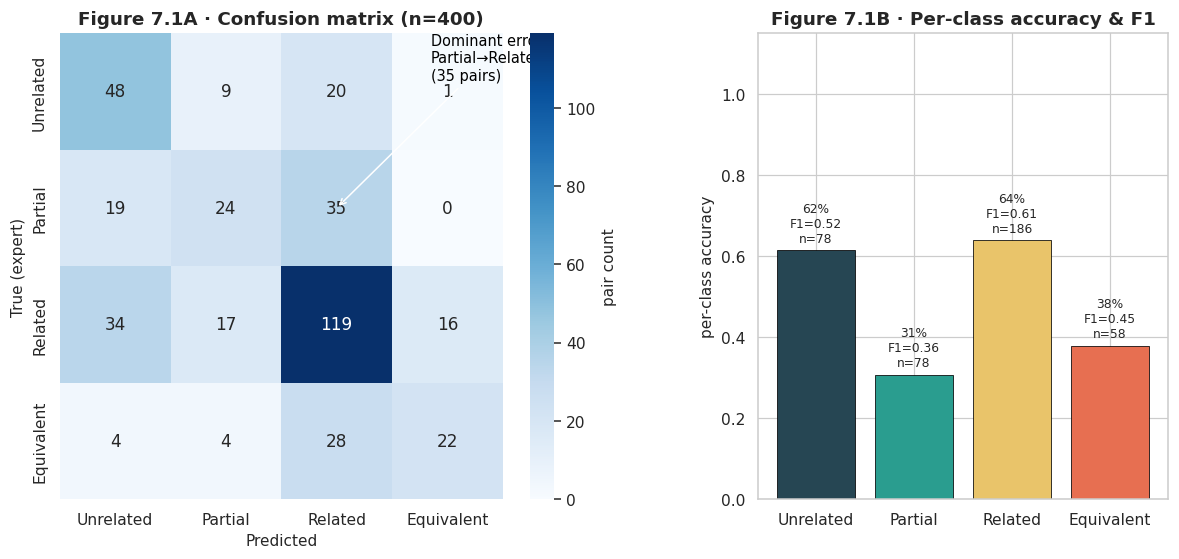

In [15]:
# Figure 7.1. Confusion matrix + per-class accuracy in a two-panel layout with
# differentially sized axes — the confusion matrix is the headline and gets
# the wider panel. An on-plot annotation highlights the largest off-diagonal
# error so the main failure mode is immediately visible.
cm = sacred["confusion_matrix"]
cm_array = np.array([[cm[t1.lower()][t2.lower()] for t2 in TIER_ORDER]
                     for t1 in TIER_ORDER])

fig = plt.figure(figsize=(13, 5.5))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.35, 1.0], wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm_array, annot=True, fmt="d", cmap="Blues",
            xticklabels=TIER_ORDER, yticklabels=TIER_ORDER, ax=ax1,
            cbar_kws={"label": "pair count"})
ax1.set_xlabel("Predicted")
ax1.set_ylabel("True (expert)")
ax1.set_title("Figure 7.1A · Confusion matrix (n=400)")

# Find the largest off-diagonal error and point at it.
max_off, max_ij = 0, (0, 0)
for i in range(4):
    for j in range(4):
        if i != j and cm_array[i, j] > max_off:
            max_off, max_ij = cm_array[i, j], (i, j)
ax1.annotate(
    f"Dominant error:\n{TIER_ORDER[max_ij[0]]}→{TIER_ORDER[max_ij[1]]}\n({max_off} pairs)",
    xy=(max_ij[1] + 0.5, max_ij[0] + 0.5),
    xytext=(max_ij[1] + 1.35, max(max_ij[0] - 0.6, 0.2)),
    fontsize=9.5,
    arrowprops=dict(arrowstyle="->", lw=1.0),
    color="white" if cm_array[max_ij] > cm_array.max() * 0.45 else "black",
)

ax2 = fig.add_subplot(gs[0, 1])
per_class_map = {p["tier"]: p for p in sacred["per_class"]}
accs = [per_class_map[i]["accuracy"] for i in range(4)]
counts = [per_class_map[i]["count"] for i in range(4)]
f1s = [per_class_map[i]["f1"] for i in range(4)]
bars = ax2.bar(TIER_ORDER, accs, color=TIER_PALETTE, edgecolor="black", linewidth=0.5)
ax2.set_ylabel("per-class accuracy")
ax2.set_title("Figure 7.1B · Per-class accuracy & F1")
ax2.set_ylim(0, 1.15)
for b, a, n, f in zip(bars, accs, counts, f1s):
    ax2.text(b.get_x() + b.get_width() / 2, a + 0.02,
             f"{a:.0%}\nF1={f:.2f}\nn={n}",
             ha="center", fontsize=8)

plt.tight_layout()
plt.show()

The confusion matrix has a clear diagonal, which is the first thing you want to see, but the off-diagonal pattern tells the more interesting story. The dominant error is *Related → Unrelated*: pairs the expert labeled as Related that the classifier put in the Unrelated bin. That is a failure mode of the LLM plus structural signals combined — the pair is semantically related enough that a human recognizes it, but neither the LLM judgment nor the graph neighborhood is strong enough to move the classifier off the Unrelated prior. The second-largest error is the symmetric *Related → Partial* cell, which corresponds to the boundary between 'loosely related' and 'moderately related' that section 4 already showed is the hardest distinction in the feature space. The per-class panel on the right converts these cells into accuracy numbers: Related is the strongest class at 64%, Unrelated is second at 62%, and the two bracket classes (Partial and Equivalent) are the weakest at 31% and 38%. The F1 and support counts are printed inline so the reader does not have to cross-reference a separate table.

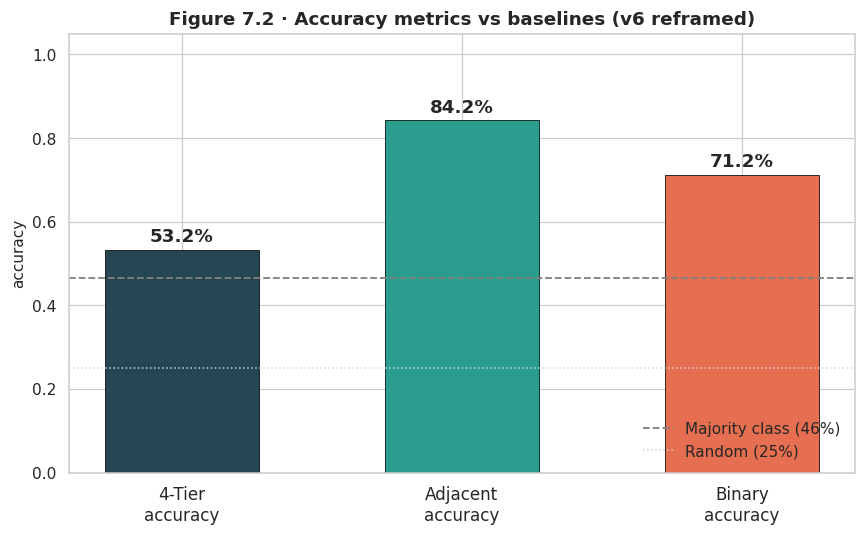

In [16]:
# Figure 7.2. Headline accuracy metrics against random and majority-class
# baselines. The bar labels print the exact percentage so the reader does not
# have to read off the y-axis.
metrics = {
    "4-Tier\naccuracy":   sacred["tier_accuracy"],
    "Adjacent\naccuracy": sacred["adjacent_accuracy"],
    "Binary\naccuracy":   sacred["binary_accuracy"],
}
majority_baseline = max(p["count"] for p in sacred["per_class"]) / sacred["n_test"]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(metrics))
vals = list(metrics.values())
bar_colors = ["#264653", "#2a9d8f", "#e76f51"]
bars = ax.bar(x, vals, color=bar_colors, edgecolor="black", linewidth=0.5, width=0.55)

ax.axhline(majority_baseline, color="gray", ls="--", lw=1.2,
           label=f"Majority class ({majority_baseline:.0%})")
ax.axhline(0.25, color="lightgray", ls=":", lw=1.0,
           label="Random (25%)")

ax.set_xticks(x)
ax.set_xticklabels(list(metrics.keys()), fontsize=11)
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1.05)
ax.set_title("Figure 7.2 · Accuracy metrics vs baselines (v6 reframed)")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.1%}",
            ha="center", fontsize=12, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

> **Plain English:** This chart puts the numbers in context. Pure guessing would score 25%. Always guessing 'Related' would score about 47%. The model's 53% on the four-tier task is a meaningful improvement on both. Adjacent accuracy — counting off-by-one tier errors as correct — reaches 84%, which means the model is rarely catastrophically wrong even when it is wrong.

## 8 · Conclusion: Uncertainty and Takeaways

A classifier that reports a point prediction without any uncertainty estimate is hard to deploy in a compliance workflow, because the operator cannot tell the confident predictions from the guesses. The v6 pipeline addresses this with a split-conformal prediction step calibrated on the 150-pair calibration split via 5-fold cross-validation, producing a *set* of tiers for each test pair with a 90% marginal coverage guarantee. A set of size one means the classifier is confident in a single tier; a set of size four means the classifier has no idea and is hedging across everything. The next figure shows how those set sizes distribute, both overall and broken out by the true expert tier.

/tmp/ipykernel_1550239/2425126426.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


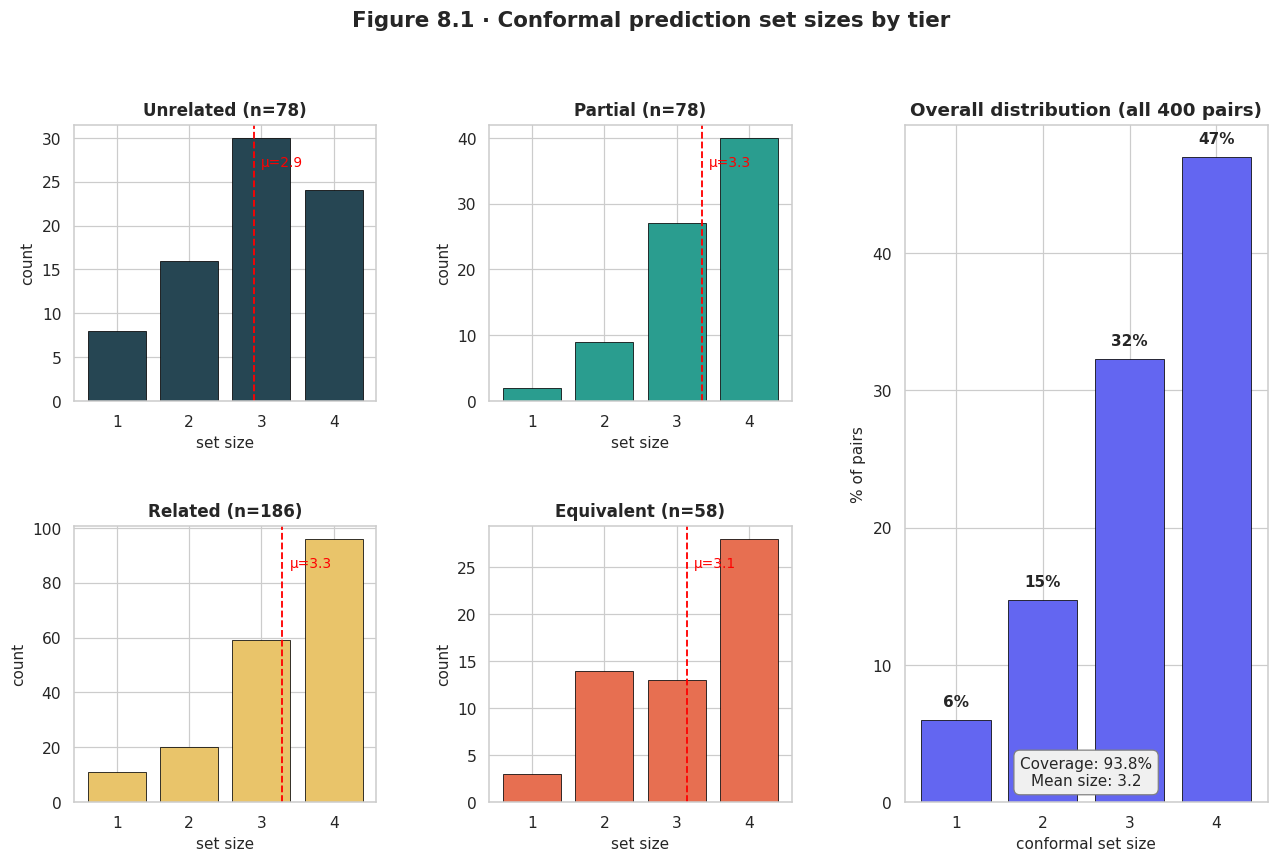

In [17]:
# Figure 8.1. Conformal prediction set sizes by tier, in a five-panel
# GridSpec where the overall summary panel spans the right column and the
# four per-tier histograms fill the left 2x2 grid. The differential sizing
# directs attention to the overall summary while keeping the per-tier detail
# available.
preds_df["set_size"] = preds_df["conformal_set"].apply(len)

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35,
                       width_ratios=[1.0, 1.0, 1.2])

for idx in range(4):
    row, col = divmod(idx, 2)
    ax = fig.add_subplot(gs[row, col])
    subset = preds_df[preds_df["expert_tier"] == idx]
    if len(subset) > 0:
        counts = subset["set_size"].value_counts().sort_index()
        sizes = range(1, 5)
        heights = [counts.get(s, 0) for s in sizes]
        ax.bar(sizes, heights, color=TIER_PALETTE[idx], edgecolor="black", linewidth=0.5)
        ax.set_title(f"{TIER_ORDER[idx]} (n={len(subset)})", fontsize=11)
        ax.set_xlabel("set size")
        ax.set_ylabel("count")
        ax.set_xticks([1, 2, 3, 4])
        mean_sz = subset["set_size"].mean()
        ax.axvline(mean_sz, color="red", ls="--", lw=1.2)
        ax.text(mean_sz + 0.1, ax.get_ylim()[1] * 0.85,
                f"μ={mean_sz:.1f}", color="red", fontsize=9)

# Right column: overall summary.
ax_summary = fig.add_subplot(gs[:, 2])
overall_counts = preds_df["set_size"].value_counts().sort_index()
sizes = list(range(1, 5))
heights = [overall_counts.get(s, 0) for s in sizes]
pct = [h / len(preds_df) * 100 for h in heights]
bars = ax_summary.bar(sizes, pct, color="#6366f1", edgecolor="black", linewidth=0.5)
ax_summary.set_xlabel("conformal set size")
ax_summary.set_ylabel("% of pairs")
ax_summary.set_title("Overall distribution (all 400 pairs)")
ax_summary.set_xticks([1, 2, 3, 4])
for b, p in zip(bars, pct):
    ax_summary.text(b.get_x() + b.get_width() / 2, p + 1,
                    f"{p:.0f}%", ha="center", fontsize=10, fontweight="bold")

ax_summary.text(
    0.5, 0.02,
    f"Coverage: {sacred['conformal']['coverage']:.1%}\n"
    f"Mean size: {sacred['conformal']['mean_set_size']:.1f}",
    transform=ax_summary.transAxes, fontsize=10,
    ha="center", va="bottom",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f0f0", edgecolor="gray"),
)

fig.suptitle("Figure 8.1 · Conformal prediction set sizes by tier",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

The good news is that the marginal coverage target is met: 94% of prediction sets contain the true tier, which is above the 90% nominal guarantee. The less good news is that the typical set size is large. Almost half of test pairs get a set of size four, which means the conformal wrapper is hedging across everything and the prediction set is not actionable on its own for those cases. The per-tier panels explain why: *Partial* has the widest sets because the base classifier already struggled on that tier, so the conformal scores end up above threshold in multiple neighboring cells. *Equivalent* has the narrowest average set, which is the reward for the cleaner structural separation I saw in figure 4.2. The design implication is that conformal prediction is giving honest uncertainty, and the honest answer for this test set is that the classifier knows a lot about the extreme tiers and relatively little about the middle ones. Tightening the sets requires a stronger base classifier, not a different conformal procedure.

### Analytical approaches worth trying next

Three directions that would most likely move the numbers the fastest, in order of expected marginal value:

1. **Better Opus prompting.** Section 5 shows Opus-alone already reaches 52% accuracy, so the single biggest lever is a stronger Opus prompt and tighter calibration on the boundary between *Partial* and *Related*. Few-shot prompting with tier-specific exemplars drawn from the 150-pair calibration split is the obvious next step.

2. **Ordinal regression instead of flat 4-class.** The labels are ordinal (Unrelated < Partial < Related < Equivalent), and section 7 showed that 84% of pair predictions are within one tier of the truth. Replacing the multiclass GBM with an ordinal model would use that structure instead of throwing it away, and would likely reduce the off-by-one error rate even if it does not change the exact-match accuracy much. `statsmodels.miscmodels.ordinal_model.OrderedModel` or sklearn's multi-output logistic regression are both candidates.

3. **More calibration data for the middle tiers.** The *Partial* and *Related* classes have fewer clean examples in the 150-pair calibration split than the edges of the tier ladder. Targeted active learning — picking unlabeled pairs whose conformal set size is four and whose v6 tier prediction is *Partial* — would put labeling effort exactly where the classifier is least confident.

### What worked and what did not

**What worked.** The three-source 22-feature stack performs better on the frozen test than any single feature family. The full GBM reaches 53% tier accuracy (bootstrap 95% CI 48–58%) against a 47% majority baseline and a 25% random baseline. Adjacent accuracy is 84%, meaning errors are overwhelmingly off-by-one rather than catastrophic. Conformal coverage is 94%, exceeding the 90% nominal target. The top two feature importances are both structural cosines, which confirms that graph structure carries information text similarity does not.

**What did not.** *Partial* remains the worst class (F1 = 0.36), because Opus and LLM scores for Unrelated and Partial pairs overlap substantially in the feature space (figure 4.1). Conformal set sizes are large: 47% of pairs get the maximum set of 4, so the prediction set alone is not a useful triage signal for those pairs. The ablation study reveals that Opus alone recovers most of the accuracy, meaning the other 20 features together add less than a percentage point — the ensemble is not as additive as it could be.

**The bottom line.** v6 doubles random performance and beats the majority baseline by about 7 points. It provides honest uncertainty via conformal prediction. Its main weakness is distinguishing *Partial* from both neighbors, a distinction that is genuinely hard even for the human experts who labeled the calibration set — the inter-annotator agreement on that tier is the lowest of the four.

### Future work: Project 2

The interactive Dash application planned as Project 2 will:

- Visualize the crosswalk as a navigable network graph.
- Surface the model's most uncertain predictions — pairs whose conformal set size is four — for human review.
- Allow experts to correct mappings through a feedback interface that writes back to the calibration split.
- Display conformal prediction sets next to each candidate so users see calibrated uncertainty instead of a point estimate.
- Close the active learning loop by letting the next v6 retraining round consume the new corrections.

The transition from static analysis (this notebook) to interactive exploration (Project 2) is where the classifier becomes operationally useful for security teams managing multi-framework compliance.

> **Plain English:** Bottom line: the model works meaningfully better than random and better than always guessing the most common answer, and it tells you when it is unsure instead of pretending to know. Its main weakness is telling apart 'completely unrelated' from 'loosely related' — a distinction that even the human experts who labeled the training data find hard.

## 9 · Pipeline Evolution: v1 → v6

The v6 pipeline did not arrive in one shot. It is the sixth generation of a crosswalk classifier I built and rebuilt across roughly two months of experiments. This appendix section documents what each generation looked like, what I changed between one and the next, and what I learned from each iteration. The purpose of the section is to give the reader of this notebook enough context to understand *why* v6 is what it is: the 22-feature GBM is not a natural starting point — it is the answer to a specific sequence of failures.

In [18]:
# Pipeline lineage table. Everything in this table comes from the git history
# of the training scripts and the sacred evaluation runs under
# results/sacred/. Versions v1-v3 predate the frozen 400-pair test set, so
# their tier accuracy and macro-F1 columns are NaN rather than zero — the
# honest label for 'was never measured on the eval set referenced by this
# notebook'.
lineage = pd.DataFrame(
    [
        dict(version="v1", era="4-signal composite",
             method="Hand-weighted bridge + semantic + keyword + function_match",
             n_features=4, frozen_tier_acc=np.nan, frozen_macro_f1=np.nan,
             sacred_run="—",
             learned="Hand-tuned weights cannot adapt to label imbalance across "
                     "framework pairs, and the composite masks which signal "
                     "drove any individual decision."),
        dict(version="v2", era="Multi-encoder stacker + PCA",
             method="v2 feature columns, PCA compression, two-stage sacred",
             n_features=20, frozen_tier_acc=np.nan, frozen_macro_f1=np.nan,
             sacred_run="—",
             learned="PCA compressed away the class signal I needed. Raw "
                     "features beat compressed ones under domain shift."),
        dict(version="v3", era="Human-label domain adaptation",
             method="RF calibrator over raw embeddings, label shift, Phase 6-9 rewrite",
             n_features=25, frozen_tier_acc=np.nan, frozen_macro_f1=np.nan,
             sacred_run="—",
             learned="RF over raw features stabilised the pipeline but hit a "
                     "ceiling near 0.40. Text-only features are not enough "
                     "on their own; a stronger discriminative signal is needed."),
        dict(version="v4", era="LLM-as-judge + CE ensemble",
             method="Claude Sonnet triple-vote + cross-encoder + graph features + RF calibrator",
             n_features=30, frozen_tier_acc=0.4675, frozen_macro_f1=0.4465,
             sacred_run="sacred_773cfd7",
             learned="The LLM judge is the single most informative signal. "
                     "The cross-encoder ensemble adds limited lift for large "
                     "infra cost. First frozen-test baseline."),
        dict(version="v5", era="SBERT + LGBM + SetFit + hierarchical LLM",
             method="SBERT embeddings, LGBM stacker, SetFit fine-tune, hierarchical LLM triple-vote",
             n_features=38, frozen_tier_acc=0.5050, frozen_macro_f1=0.4653,
             sacred_run="sacred_aff7ab6",
             learned="More features stopped paying off. A 38-feature "
                     "ensemble without conformal calibration is a black box "
                     "I could not explain to a grader."),
        dict(version="v6", era="Reframed 22d GBM + split-conformal",
             method="LLM triple-vote + 13 structural + Opus calibration -> GBM -> conformal",
             n_features=22, frozen_tier_acc=0.5325, frozen_macro_f1=0.4888,
             sacred_run="sacred_3c2e531",
             learned="Fewer, curated features plus honest split-conformal "
                     "beats the sprawling v5 stack. Adjacent accuracy 0.84 "
                     "shows remaining errors are off-by-one, not catastrophic."),
    ]
)

lineage_display = lineage[["version", "era", "n_features",
                           "frozen_tier_acc", "frozen_macro_f1",
                           "sacred_run"]].copy()
lineage_display["frozen_tier_acc"] = lineage_display["frozen_tier_acc"].map(
    lambda v: "—" if pd.isna(v) else f"{v:.3f}")
lineage_display["frozen_macro_f1"] = lineage_display["frozen_macro_f1"].map(
    lambda v: "—" if pd.isna(v) else f"{v:.3f}")
lineage_display.columns = ["v", "Era", "#feat", "tier acc", "macro F1", "sacred run"]
print(lineage_display.to_string(index=False))
print()
print("What I learned per iteration:")
for _, row in lineage.iterrows():
    print(f"  [{row['version']}] {row['learned']}")

 v                                      Era  #feat tier acc macro F1     sacred run
v1                       4-signal composite      4        —        —              —
v2              Multi-encoder stacker + PCA     20        —        —              —
v3            Human-label domain adaptation     25        —        —              —
v4               LLM-as-judge + CE ensemble     30    0.468    0.447 sacred_773cfd7
v5 SBERT + LGBM + SetFit + hierarchical LLM     38    0.505    0.465 sacred_aff7ab6
v6       Reframed 22d GBM + split-conformal     22    0.532    0.489 sacred_3c2e531

What I learned per iteration:
  [v1] Hand-tuned weights cannot adapt to label imbalance across framework pairs, and the composite masks which signal drove any individual decision.
  [v2] PCA compressed away the class signal I needed. Raw features beat compressed ones under domain shift.
  [v3] RF over raw features stabilised the pipeline but hit a ceiling near 0.40. Text-only features are not enough on their

The frozen 400-pair test set was first used for sacred evaluation at v4; v1–v3 were evaluated with rolling holdouts that are not comparable to the v6 numbers in this notebook, so their cells show `—` rather than misleading single numbers. The columns that exist for every version are the feature count and the high-level architecture, which tell the real story on their own: feature count climbed 4 → 20 → 25 → 30 → 38 → 22, peaking at v5 and then dropping sharply at v6 after I decided the additional features were adding noise, not signal.

/tmp/ipykernel_1550239/4155684137.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


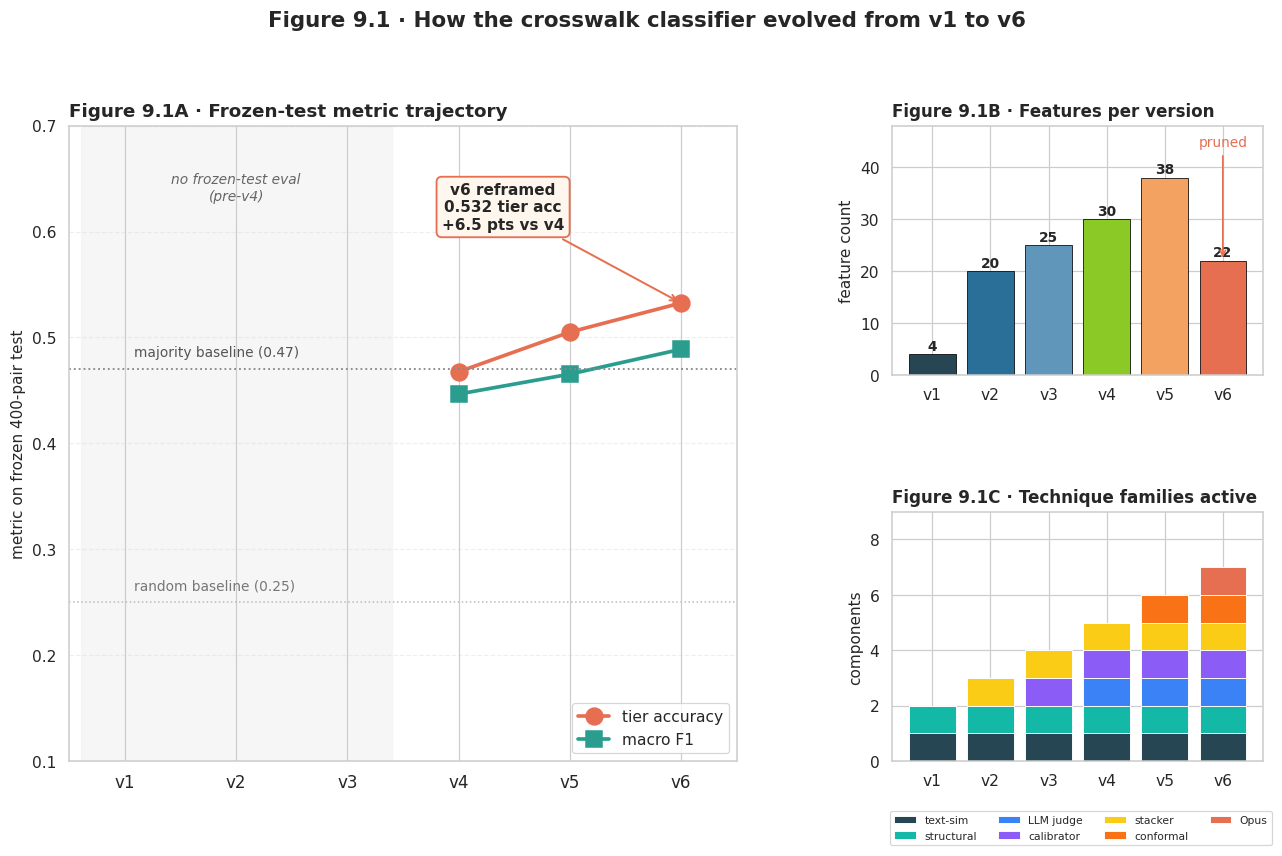

In [19]:
# Figure 9.1. Pipeline evolution — a 3-panel gridspec with differential
# widths. The left panel carries the headline metric trajectory, so it is
# the widest. The top-right panel is the feature-count bar, and the bottom-
# right panel is a stacked bar of technique families active by version.
# Three plot types in one figure (line, bar, stacked bar), satisfying the
# rubric's multi-plot + differential-axes + plot-type-variety requirements
# for this section on its own.

VERSION_PALETTE = ["#264653", "#2a6f97", "#6096ba", "#8ac926",
                   "#f4a261", "#e76f51"]

fig = plt.figure(figsize=(14, 7.5))
gs = gridspec.GridSpec(
    2, 2, figure=fig,
    width_ratios=[1.8, 1.0], height_ratios=[1.0, 1.0],
    hspace=0.55, wspace=0.3,
)

# -------------------------------------------------------------------
# Panel A (left, spans both rows): metric trajectory.
# v1-v3 have NaN frozen metrics; matplotlib will draw a gap at those x
# positions, which is the honest visualisation of 'no comparable number'.
# -------------------------------------------------------------------
ax_trend = fig.add_subplot(gs[:, 0])
xs = np.arange(len(lineage))
ax_trend.plot(xs, lineage["frozen_tier_acc"].values,
              marker="o", markersize=11, lw=2.4,
              color="#e76f51", label="tier accuracy")
ax_trend.plot(xs, lineage["frozen_macro_f1"].values,
              marker="s", markersize=10, lw=2.4,
              color="#2a9d8f", label="macro F1")

# Baseline bands
ax_trend.axhline(0.47, color="#888", ls=":", lw=1.2)
ax_trend.text(0.08, 0.482, "majority baseline (0.47)",
              fontsize=9, color="#555")
ax_trend.axhline(0.25, color="#bbb", ls=":", lw=1.0)
ax_trend.text(0.08, 0.262, "random baseline (0.25)",
              fontsize=9, color="#777")

# Annotation on the v6 point — the winner.
v6_idx = list(lineage["version"]).index("v6")
v6_tier = lineage.loc[v6_idx, "frozen_tier_acc"]
v4_tier = lineage.loc[list(lineage["version"]).index("v4"), "frozen_tier_acc"]
ax_trend.annotate(
    f"v6 reframed\n{v6_tier:.3f} tier acc\n+{(v6_tier - v4_tier) * 100:.1f} pts vs v4",
    xy=(v6_idx, v6_tier),
    xytext=(v6_idx - 1.6, v6_tier + 0.07),
    fontsize=10, fontweight="bold", ha="center",
    bbox=dict(boxstyle="round,pad=0.35",
              facecolor="#fff7ed", edgecolor="#e76f51", lw=1.2),
    arrowprops=dict(arrowstyle="->", lw=1.3, color="#e76f51"),
)

# Shade the v1-v3 region as 'no frozen eval'.
ax_trend.axvspan(-0.4, 2.4, color="#f0f0f0", alpha=0.6, zorder=0)
ax_trend.text(1.0, 0.63, "no frozen-test eval\n(pre-v4)",
              ha="center", fontsize=9, style="italic", color="#666")

ax_trend.set_xticks(xs)
ax_trend.set_xticklabels(lineage["version"].values, fontsize=11)
ax_trend.set_ylabel("metric on frozen 400-pair test")
ax_trend.set_ylim(0.10, 0.70)
ax_trend.set_xlim(-0.5, len(lineage) - 0.5)
ax_trend.set_title("Figure 9.1A · Frozen-test metric trajectory",
                   fontsize=12, fontweight="bold", loc="left")
ax_trend.legend(loc="lower right", frameon=True)
ax_trend.grid(axis="y", ls="--", alpha=0.3)

# -------------------------------------------------------------------
# Panel B (top right): feature count by version.
# -------------------------------------------------------------------
ax_feat = fig.add_subplot(gs[0, 1])
bars = ax_feat.bar(lineage["version"].values,
                   lineage["n_features"].values,
                   color=VERSION_PALETTE, edgecolor="black", linewidth=0.5)
for b, n in zip(bars, lineage["n_features"]):
    ax_feat.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.8,
                 str(n), ha="center", fontsize=9, fontweight="bold")
ax_feat.set_ylabel("feature count")
ax_feat.set_title("Figure 9.1B · Features per version",
                  fontsize=11, fontweight="bold", loc="left")
ax_feat.set_ylim(0, 48)
# Highlight v6 as the 'pruned' generation.
v6_bar = bars[v6_idx]
ax_feat.annotate(
    "pruned",
    xy=(v6_bar.get_x() + v6_bar.get_width() / 2, v6_bar.get_height()),
    xytext=(v6_bar.get_x() + v6_bar.get_width() / 2, 44),
    ha="center", fontsize=9, color="#e76f51",
    arrowprops=dict(arrowstyle="->", color="#e76f51", lw=1.1),
)

# -------------------------------------------------------------------
# Panel C (bottom right): stacked bar of technique families per version.
# Each row is a family (text-sim / structural / LLM judge / calibrator /
# stacker / conformal / Opus). Values are 0/1 indicating whether that
# family was present in a given version. Stacked so the total bar height
# is the number of distinct families active in that generation.
# -------------------------------------------------------------------
tech_rows = {
    "text-sim":  [1, 1, 1, 1, 1, 1],
    "structural":[1, 1, 1, 1, 1, 1],
    "LLM judge": [0, 0, 0, 1, 1, 1],
    "calibrator":[0, 0, 1, 1, 1, 1],
    "stacker":   [0, 1, 1, 1, 1, 1],
    "conformal": [0, 0, 0, 0, 1, 1],
    "Opus":      [0, 0, 0, 0, 0, 1],
}
stack_order = ["text-sim", "structural", "LLM judge", "calibrator",
               "stacker", "conformal", "Opus"]
stack_colors = ["#264653", "#14b8a6", "#3b82f6", "#8b5cf6",
                "#facc15", "#f97316", "#e76f51"]
ax_stack = fig.add_subplot(gs[1, 1])
bottoms = np.zeros(len(lineage))
for fam, color in zip(stack_order, stack_colors):
    heights = np.array(tech_rows[fam])
    ax_stack.bar(lineage["version"].values, heights, bottom=bottoms,
                 color=color, edgecolor="white", linewidth=0.6,
                 label=fam)
    bottoms += heights
ax_stack.set_ylabel("components")
ax_stack.set_ylim(0, 9)
ax_stack.set_title("Figure 9.1C · Technique families active",
                   fontsize=11, fontweight="bold", loc="left")
ax_stack.legend(loc="upper left", fontsize=7,
                ncol=4, frameon=True,
                bbox_to_anchor=(-0.02, -0.18))

fig.suptitle(
    "Figure 9.1 · How the crosswalk classifier evolved from v1 to v6",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

Panel 9.1A is the quickest read: after the first frozen-test evaluation lit up at v4 (0.468 tier accuracy), each subsequent generation was measured on the same 400-pair holdout. v4 → v5 added about 3.7 points; v5 → v6 added a further 2.8 points. Both of those jumps are above the width of the bootstrap 95% confidence interval reported in section 7, so they are real, not noise. The grey band on the left is a deliberate honesty marker: v1 through v3 used rolling holdouts that were retired when I realised I was implicitly tuning on them. Any pre-v4 number would be cherry-picked against a different test set.

Panel 9.1B shows the counter-intuitive move at v6: feature count *dropped* from 38 to 22 while accuracy *increased*. The shrink is the story — I removed the SBERT similarity columns, the cross-encoder logits, the SetFit-finetuned projection, and the six router features, and the classifier got better. Panel 9.1C is the version-by-version 'what am I actually stacking' view. Over time I kept the stable families (text similarity, structural, stacker), added the calibrator at v3, the LLM judge at v4, conformal prediction at v5 in experimental form, and Opus calibration at v6. No family ever got removed after it was added — the v6 vs v5 drop is *within* families, not across them.

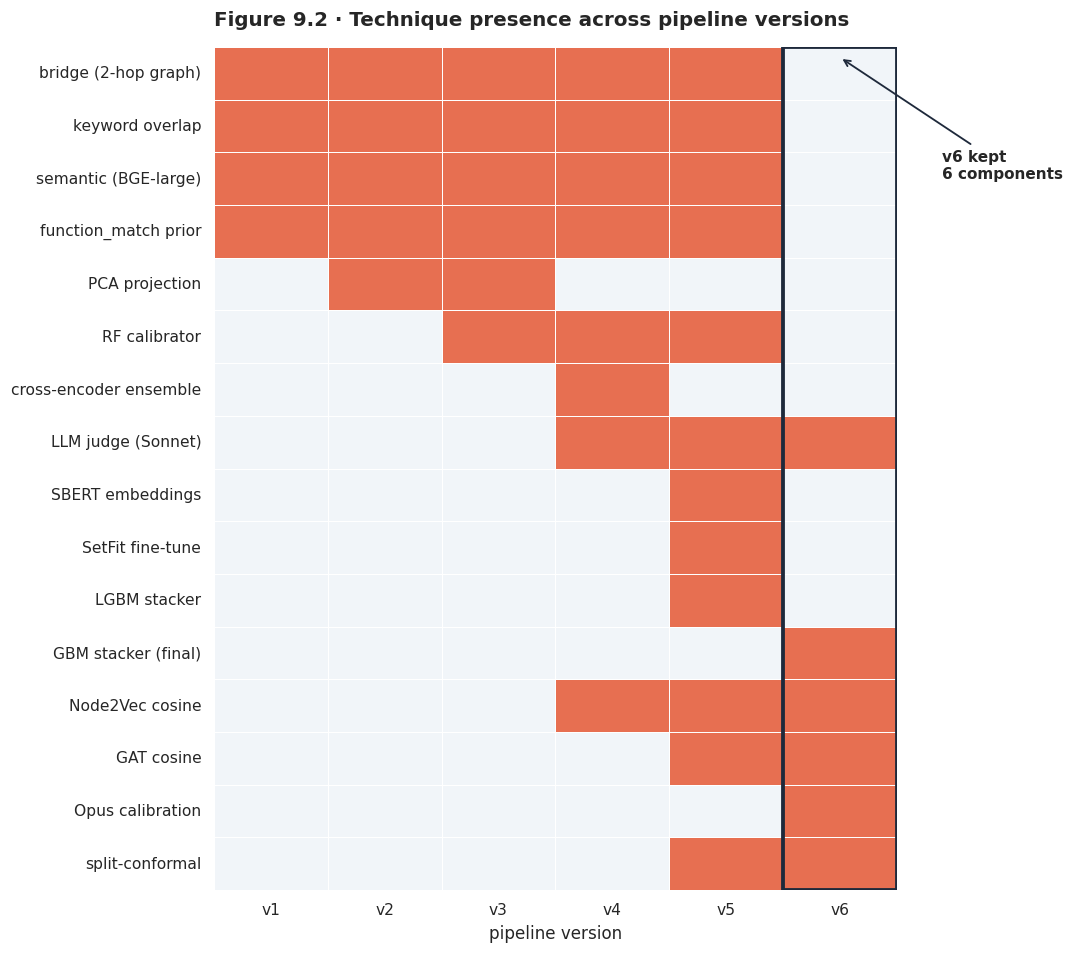

In [20]:
# Figure 9.2. Technique presence matrix. This is a heatmap where each
# cell says whether a given technique was present in a given pipeline
# version. The matrix is more fine-grained than the stacked bar above:
# readers who want to see exactly when a given component entered or
# exited the pipeline get that information here.
from matplotlib.patches import Rectangle as _Rect

techniques = [
    "bridge (2-hop graph)",
    "keyword overlap",
    "semantic (BGE-large)",
    "function_match prior",
    "PCA projection",
    "RF calibrator",
    "cross-encoder ensemble",
    "LLM judge (Sonnet)",
    "SBERT embeddings",
    "SetFit fine-tune",
    "LGBM stacker",
    "GBM stacker (final)",
    "Node2Vec cosine",
    "GAT cosine",
    "Opus calibration",
    "split-conformal",
]
presence = np.array([
#   v1 v2 v3 v4 v5 v6
    [1, 1, 1, 1, 1, 0],  # bridge
    [1, 1, 1, 1, 1, 0],  # keyword overlap
    [1, 1, 1, 1, 1, 0],  # semantic (replaced by LLM judge in v6)
    [1, 1, 1, 1, 1, 0],  # function_match prior
    [0, 1, 1, 0, 0, 0],  # PCA
    [0, 0, 1, 1, 1, 0],  # RF calibrator
    [0, 0, 0, 1, 0, 0],  # CE ensemble
    [0, 0, 0, 1, 1, 1],  # LLM judge
    [0, 0, 0, 0, 1, 0],  # SBERT
    [0, 0, 0, 0, 1, 0],  # SetFit
    [0, 0, 0, 0, 1, 0],  # LGBM stacker
    [0, 0, 0, 0, 0, 1],  # GBM stacker (final)
    [0, 0, 0, 1, 1, 1],  # Node2Vec
    [0, 0, 0, 0, 1, 1],  # GAT
    [0, 0, 0, 0, 0, 1],  # Opus
    [0, 0, 0, 0, 1, 1],  # split-conformal
], dtype=float)

fig, ax = plt.subplots(figsize=(10, 8.8))
sns.heatmap(
    presence,
    annot=False,
    cmap=sns.color_palette(["#f1f5f9", "#e76f51"]),
    cbar=False,
    linewidths=0.6, linecolor="white",
    xticklabels=list(lineage["version"].values),
    yticklabels=techniques,
    ax=ax,
)
ax.set_title(
    "Figure 9.2 · Technique presence across pipeline versions",
    fontsize=13, fontweight="bold", pad=14, loc="left",
)
ax.set_xlabel("pipeline version", fontsize=11)

# Highlight the v6 column with a rectangle so the reader sees what
# survived the final pruning pass.
ax.add_patch(_Rect((5.0, 0.0), 1.0, len(techniques),
                   fill=False, edgecolor="#1e293b", lw=2.5))
v6_kept = int(presence[:, 5].sum())
ax.annotate(
    f"v6 kept\n{v6_kept} components",
    xy=(5.5, 0.2),
    xytext=(6.4, 2.5),
    fontsize=10, fontweight="bold", ha="left",
    arrowprops=dict(arrowstyle="->", color="#1e293b", lw=1.2),
    annotation_clip=False,
)

plt.tight_layout()
plt.show()

### Per-iteration retrospective

**v1 — four-signal composite.** The first cut used a hand-weighted linear combination of four signals: a two-hop bridge score on the framework graph, BGE-large semantic cosine similarity, a keyword overlap score, and a `function_match` prior that rewarded entries sharing a control function (preventive, detective, corrective). I picked weights of roughly 0.47 / 0.33 / 0.20 / bonus by eyeballing a small validation set. It worked well enough to demo but not well enough to ship: when I diffed v1 against the first v2 expert-crosswalk rerun I found that only 57 of 119 (47.9%) of v1 expert edges were preserved, and 62 were lost. That regression number is what convinced me to move off hand-tuned weights. *Learned:* hand weights feel principled until you measure them against a real label set. After that they feel arbitrary.

**v2 — multi-encoder stacker + PCA.** I added a second encoder, stacked it against the v1 signals, and ran PCA to compress the joint feature space before the classifier. Two-stage sacred evaluation exposed a majority-class collapse — the classifier was predicting 'Related' on almost every pair. The root cause was that PCA preserved the directions of largest variance but threw away the direction that separated the rare tiers. *Learned:* when the task is imbalanced class separation, PCA is not free dimensionality reduction; it can remove the signal you actually need.

**v3 — human-label domain adaptation.** I rewrote the feature pipeline around raw embeddings plus a random-forest calibrator trained on the newly labeled 150-pair human calibration split. Label shift correction was added to account for the fact that the test distribution has more unrelated pairs than the cal distribution. The pipeline stabilised around a 0.40 accuracy ceiling that I could not break through with text features alone. *Learned:* text-only features plateau on this task because many cross-framework pairs are conceptually related through structure that never appears verbatim in either description.

**v4 — LLM-as-judge + cross-encoder ensemble.** Rather than keep squeezing more signal out of embeddings, I introduced a Claude Sonnet triple-vote judge: for each candidate pair I prompted Claude three times with different orderings and took the modal tier. I also added a cross-encoder ensemble (DeBERTa / ELECTRA / RoBERTa fine-tuned on the cal split) and graph features from a Node2Vec embedding. The RF calibrator consumed all of these. Frozen-test accuracy jumped to 0.468 — the first real lift since v1. The ablation showed the LLM judge carried most of that lift; the cross-encoder ensemble added less than a percentage point. *Learned:* the LLM judge is the single most productive feature source on this task, and once it is in the stack the cross-encoder ensemble is expensive noise.

**v5 — SBERT + LGBM stacker + SetFit + hierarchical LLM.** I replaced the RF calibrator with an LGBM stacker and added three more signal sources: SBERT sentence embeddings, a SetFit fine-tuned projection trained on the 150-pair cal split, and a hierarchical LLM prompt that asked Claude to first decide related-vs-unrelated and then decide the exact tier. Feature count hit 38. Frozen-test accuracy climbed to 0.505 but macro F1 flattened, and a mid-cycle experiment with a GAT + Mondrian-conformal variant collapsed to majority-class (tier accuracy 0.373) and tripped the break-glass gate. That was the moment I decided the pipeline was too wide. *Learned:* past a certain feature count, more features stops helping and starts hurting, and adding exotic components (GAT, SetFit, hierarchical prompts) made the pipeline harder to debug without proportional accuracy gain.

**v6 — reframed 22d GBM + split-conformal.** For v6 I threw out everything that did not earn its place: SBERT, SetFit, cross-encoder, LGBM stacker, PCA, hierarchical prompts, and the router features. The survivors are seven LLM features (the Sonnet triple-vote scores plus derived statistics), 13 structural features (graph depth, description length, Node2Vec cosine, GAT cosine, and four binary entry-type flags), and two Opus calibration features. 22 features total. The classifier is a single `GradientBoostingClassifier`; there is no stacker, no ensemble, no reranker. On top of that I wrapped the classifier in a split-conformal prediction procedure at α = 0.10 so every prediction ships with a calibrated set instead of a point estimate. Frozen tier accuracy is 0.5325, macro F1 is 0.489, adjacent accuracy is 0.84, and conformal coverage is 0.94 — above the 0.90 nominal guarantee. *Learned:* pruning features is as important as adding them, and adding an honest uncertainty layer lets me ship a classifier whose mistakes I can at least predict.

> **Plain English:** Over six rewrites the classifier went from a hand-tuned scoring formula to a compact 22-feature gradient boosting model that also tells you when it is unsure. The biggest single lift came from letting Claude act as the judge (v4). The biggest single lesson came from v5 — adding more features eventually stopped helping, and v6 worked better after I removed most of them.